In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy
77295,77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy
77296,77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny
77297,77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny


In [4]:
df.isna().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [6]:
df.describe()

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


In [7]:
df.columns

Index(['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType',
       'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature',
       'Weather'],
      dtype='object')

In [8]:
for col in df.columns:
    print(df[col].value_counts())

Index
0        1
1        1
2        1
3        1
4        1
        ..
77294    1
77295    1
77296    1
77297    1
77298    1
Name: count, Length: 77299, dtype: int64
geohash
qp03wd    105
qp03wf    105
qp09t0    105
qp03w9    105
qp03x3    105
         ... 
qp08gs      1
qp08fq      1
qp0d1t      1
qp09vc      1
qp09jc      1
Name: count, Length: 1249, dtype: int64
day
48    69427
49     7872
Name: count, dtype: int64
timestamp
2:0      1778
1:45     1755
1:30     1750
1:15     1698
1:0      1668
         ... 
19:30     308
18:30     303
18:45     297
19:0      292
19:15     288
Name: count, Length: 96, dtype: int64
demand
1.000000    585
0.027132      1
0.003272      1
0.010819      1
0.016262      1
           ... 
0.063599      1
0.022749      1
0.093100      1
0.024143      1
0.118507      1
Name: count, Length: 76715, dtype: int64
RoadType
Residential    69230
Street          3909
Highway         3560
Name: count, dtype: int64
NumberofLanes
1    27411
2    24127
3    23919
4    

<Axes: ylabel='Temperature'>

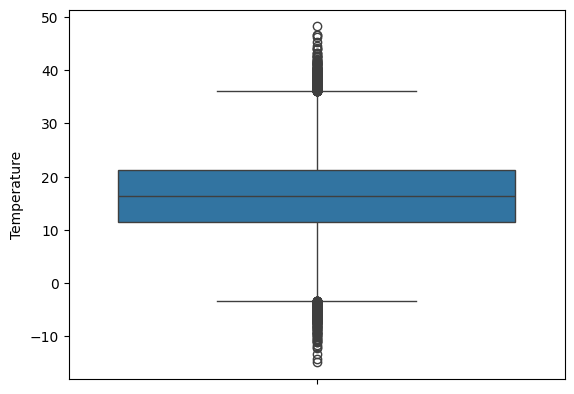

In [9]:
sns.boxplot(df['Temperature'])

<Axes: xlabel='Weather', ylabel='Temperature'>

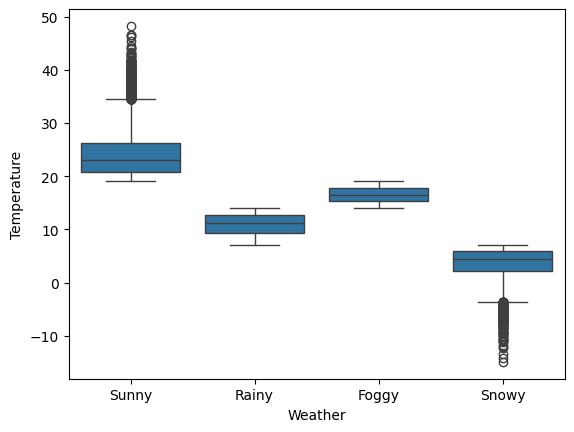

In [10]:
sns.boxplot(x='Weather', y='Temperature', data=df)

In [11]:
df['Weather'].value_counts()

Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
Name: count, dtype: int64

In [12]:
df[df['Weather'].isna() & df['Temperature'].isna()]

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
3007,3007,qp091t,48,1:0,0.030008,Residential,3,Allowed,Yes,NaN,NaN
6014,6014,qp03z6,48,1:45,0.002964,Residential,1,Not Allowed,No,NaN,NaN
9021,9021,qp094j,48,2:45,0.002178,Residential,2,Not Allowed,Yes,NaN,NaN
12028,12028,qp09e4,48,3:30,0.085958,Residential,3,Allowed,Yes,NaN,NaN
15035,15035,qp09uk,48,4:15,0.014084,Residential,1,Not Allowed,No,NaN,NaN
18042,18042,qp03p1,48,5:15,0.039419,Residential,3,Allowed,Yes,NaN,NaN
21049,21049,qp03my,48,6:0,0.093137,Residential,3,Allowed,Yes,NaN,NaN
24056,24056,qp099z,48,6:45,0.014960,Residential,3,Allowed,Yes,NaN,NaN
27063,27063,qp08fy,48,7:45,0.021989,Residential,2,Not Allowed,Yes,NaN,NaN


In [13]:
rows_to_drop = df[df['Weather'].isna() & df['Temperature'].isna()].index
df = df.drop(rows_to_drop)

In [14]:
df

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
5,5,qp02zw,48,0:0,0.016262,Residential,2,Not Allowed,Yes,8.446025,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy
77295,77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy
77296,77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny
77297,77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny


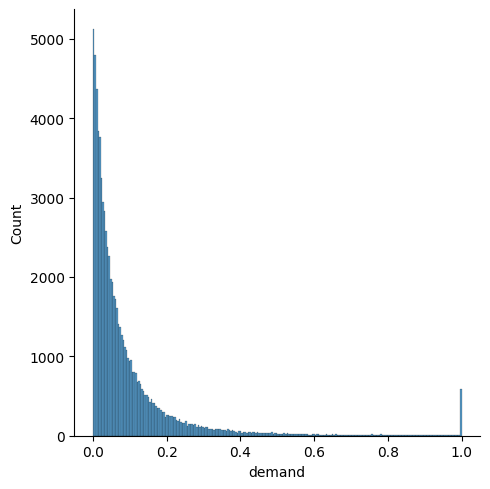

In [15]:
sns.displot(df['demand'])

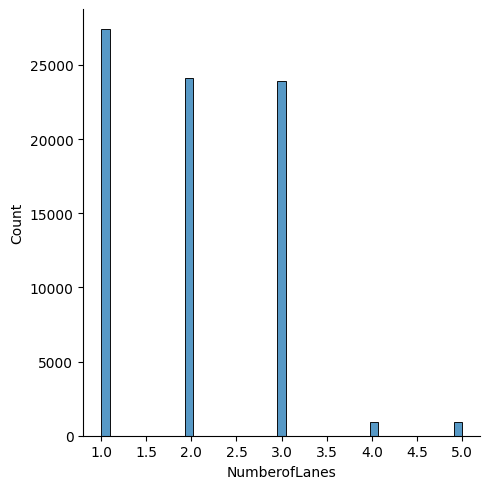

In [16]:
sns.displot(df['NumberofLanes'])

In [17]:
df.drop(columns=['Index'], inplace=True)

In [18]:
df['Weather'].value_counts()

Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
Name: count, dtype: int64

In [19]:
df.isna().sum()

geohash             0
day                 0
timestamp           0
demand              0
RoadType          599
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2469
Weather           771
dtype: int64

In [20]:
df[df['Weather'].isna()]

,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
97,qp03pr,48,0:0,0.075934,Residential,3,Allowed,Yes,20.290262,NaN
194,qp09ke,48,0:0,0.062698,Residential,3,Allowed,Yes,12.675770,NaN
291,qp03x2,48,0:0,0.023717,Residential,3,Allowed,Yes,24.700395,NaN
388,qp03ws,48,0:0,0.036228,Residential,2,Not Allowed,Yes,12.773994,NaN
485,qp03y8,48,0:0,0.056283,Residential,1,Not Allowed,No,15.221394,NaN
...,...,...,...,...,...,...,...,...,...,...
76824,qp03tf,49,2:0,0.058770,Residential,3,Allowed,Yes,16.052896,NaN
76921,qp03xt,49,2:0,0.372385,Highway,4,Allowed,Yes,23.180955,NaN
77018,qp09u2,49,2:0,0.040699,Residential,3,Allowed,Yes,23.360023,NaN
77115,qp09vk,49,2:0,0.150193,Residential,3,Allowed,Yes,16.396076,NaN


<Axes: xlabel='Weather', ylabel='Temperature'>

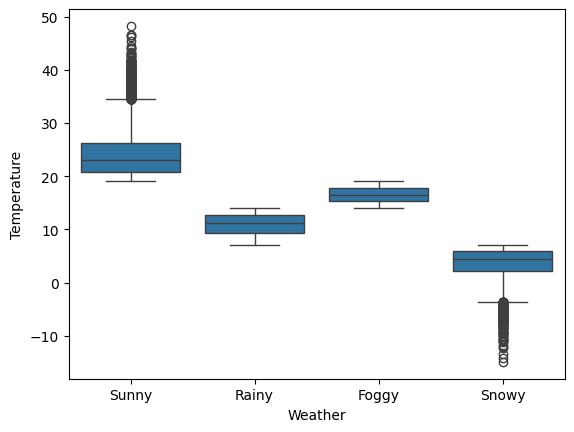

In [21]:
sns.boxplot(x='Weather', y='Temperature', data=df)

In [22]:
df.columns

Index(['geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes',
       'LargeVehicles', 'Landmarks', 'Temperature', 'Weather'],
      dtype='object')

In [23]:
df['Weather'].unique()

array(['Sunny', 'Rainy', 'Foggy', 'Snowy', nan], dtype=object)

In [24]:
df[df['Weather'] == 'Sunny']

,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
11,qp02zr,48,0:0,0.089060,Residential,2,Not Allowed,Yes,19.245381,Sunny
16,qp08bz,48,0:0,0.001492,Residential,1,Not Allowed,No,19.266717,Sunny
17,qp08cp,48,0:0,0.003284,Residential,3,Allowed,Yes,24.318534,Sunny
...,...,...,...,...,...,...,...,...,...,...
77288,qp06py,49,2:0,0.063179,Residential,2,Not Allowed,Yes,28.022363,Sunny
77289,qp0d0n,49,2:0,0.027741,Residential,3,Allowed,Yes,26.176992,Sunny
77292,qp0d1q,49,2:0,0.007453,Residential,3,Allowed,Yes,19.906633,Sunny
77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny


In [25]:
weather_median = df.groupby('Weather')['Temperature'].median()
weather_median

Weather
Foggy    16.475623
Rainy    11.141699
Snowy     4.403676
Sunny    23.049061
Name: Temperature, dtype: float64

In [26]:
mask = df['Temperature'].isna() & df['Weather'].notna()

df.loc[mask, 'Temperature'] = (
    df.loc[mask, 'Weather'].map(weather_median)
)

In [27]:
df.groupby('Weather')['Temperature'].median().sort_values()

Weather
Snowy     4.403676
Rainy    11.141699
Foggy    16.475623
Sunny    23.049061
Name: Temperature, dtype: float64

In [28]:
# snowy_rainy = (4.403676 + 11.141699) / 2   # 7.77
# rainy_foggy = (11.141699 + 16.475623) / 2  # 13.81
# foggy_sunny = (16.475623 + 23.049061) / 2  # 19.76
def infer_weather(temp):
    if temp < 7.77:
        return 'Snowy'
    elif temp < 13.81:
        return 'Rainy'
    elif temp < 19.76:
        return 'Foggy'
    else:
        return 'Sunny'

In [29]:
known = df[df['Weather'].notna()].copy()

known['pred_weather'] = known['Temperature'].apply(infer_weather)

accuracy = (
    known['pred_weather'] == known['Weather']
).mean()

print(f"Accuracy = {accuracy:.4f}")

Accuracy = 0.9336


In [30]:
mask = df['Weather'].isna()

df.loc[mask, 'Weather'] = (
    df.loc[mask, 'Temperature'].apply(infer_weather)
)

In [31]:
df.isna().sum()

geohash            0
day                0
timestamp          0
demand             0
RoadType         599
NumberofLanes      0
LargeVehicles      0
Landmarks          0
Temperature        0
Weather            0
dtype: int64

In [32]:
# No missing values left
df[['Temperature', 'Weather']].isna().sum()

Temperature    0
Weather        0
dtype: int64

In [33]:
# Check weather distribution
df['Weather'].value_counts(normalize=True)

Weather
Sunny    0.362002
Rainy    0.272074
Foggy    0.265021
Snowy    0.100902
Name: proportion, dtype: float64

In [34]:
df['RoadType'].value_counts()

RoadType
Residential    69206
Street          3909
Highway         3559
Name: count, dtype: int64

In [35]:
df['RoadType'].unique()

array(['Residential', 'Street', nan, 'Highway'], dtype=object)

In [36]:
df['NumberofLanes'].value_counts()

NumberofLanes
1    27401
2    24119
3    23911
4      926
5      916
Name: count, dtype: int64

<Axes: xlabel='RoadType', ylabel='NumberofLanes'>

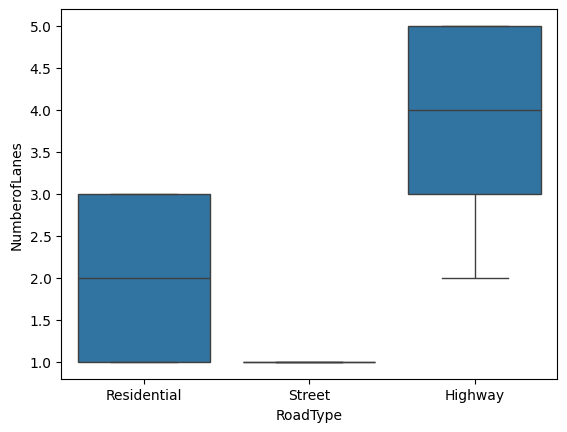

In [37]:
sns.boxplot(y='NumberofLanes', x='RoadType', data=df)

In [38]:
pd.crosstab(
    df['NumberofLanes'],
    df['RoadType'],
    margins=True
)

RoadType,Highway,Residential,Street,All
NumberofLanes,,,,
1,0,23260,3909,27169
2,854,23084,0,23938
3,881,22862,0,23743
4,915,0,0,915
5,909,0,0,909
All,3559,69206,3909,76674


In [39]:
df.groupby('geohash')['RoadType'].nunique().value_counts()

RoadType
1    994
2    128
3    127
Name: count, dtype: int64

In [40]:
missing = df[df['RoadType'].isna()]

missing['NumberofLanes'].value_counts()

NumberofLanes
1    232
2    181
3    168
4     11
5      7
Name: count, dtype: int64

In [41]:
pd.crosstab(df['LargeVehicles'], df['RoadType'])

RoadType,Highway,Residential,Street
LargeVehicles,,,
Allowed,3559,22862,0
Not Allowed,0,46344,3909


In [42]:
pd.crosstab(df['Landmarks'], df['RoadType'])

RoadType,Highway,Residential,Street
Landmarks,,,
No,1763,23260,0
Yes,1796,45946,3909


In [43]:
def infer_roadtype(lanes, large_vehicles):
    
    if large_vehicles == 'Allowed':
        if lanes >= 4:
            return 'Highway'
        elif lanes in [2, 3]:
            return 'Residential'  # could be Highway, but Residential is much more common
        else:
            return 'Residential'

    else:  # Not Allowed
        if lanes == 1:
            return 'Street'
        else:
            return 'Residential'

In [44]:
known = df[df['RoadType'].notna()].copy()

known['pred'] = known.apply(
    lambda row: infer_roadtype(
        row['NumberofLanes'],
        row['LargeVehicles']
    ),
    axis=1
)

(known['pred'] == known['RoadType']).mean()

np.float64(0.674009442575058)

In [45]:
pd.crosstab(
    [df['NumberofLanes'], df['LargeVehicles']],
    df['RoadType']
)

RoadType                     Highway  Residential  Street
NumberofLanes LargeVehicles                              
1             Not Allowed          0        23260    3909
2             Allowed            854            0       0
              Not Allowed          0        23084       0
3             Allowed            881        22862       0
4             Allowed            915            0       0
5             Allowed            909            0       0

In [46]:
mapping = (
    df[df['RoadType'].notna()]
    .groupby(['NumberofLanes', 'LargeVehicles'])['RoadType']
    .agg(lambda x: x.mode().iloc[0])
)

print(mapping)

NumberofLanes  LargeVehicles
1              Not Allowed      Residential
2              Allowed              Highway
               Not Allowed      Residential
3              Allowed          Residential
4              Allowed              Highway
5              Allowed              Highway
Name: RoadType, dtype: object


In [47]:
df[df['RoadType'].isna()][['NumberofLanes', 'LargeVehicles']].drop_duplicates()

,NumberofLanes,LargeVehicles
129,2,Not Allowed
258,1,Not Allowed
387,3,Allowed
4902,5,Allowed
10191,4,Allowed
15093,2,Allowed


In [48]:
mapping = (
    df[df['RoadType'].notna()]
    .groupby(['NumberofLanes', 'LargeVehicles'])['RoadType']
    .agg(lambda x: x.mode().iloc[0])
)

mask = df['RoadType'].isna()

df.loc[mask, 'RoadType'] = df.loc[mask].apply(
    lambda row: mapping.loc[
        (row['NumberofLanes'], row['LargeVehicles'])
    ],
    axis=1
)

In [49]:
df.isna().sum()

geohash          0
day              0
timestamp        0
demand           0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64

## Feature Engineering

In [50]:
df['hour'] = df['timestamp'].str.split(':').str[0].astype(int)
df['minute'] = df['timestamp'].str.split(':').str[1].astype(int)

In [51]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

In [52]:
df['LargeVehicles'] = df['LargeVehicles'].map({
    'Allowed': 1,
    'Not Allowed': 0
})

df['Landmarks'] = df['Landmarks'].map({
    'Yes': 1,
    'No': 0
})

In [53]:
df['minute'].value_counts()

minute
0     19970
45    19154
30    19111
15    19038
Name: count, dtype: int64

In [54]:
df['hour'].value_counts()

hour
1     6868
0     6336
2     4454
4     3682
6     3663
10    3621
5     3620
3     3594
7     3568
11    3565
9     3548
12    3524
8     3506
13    3270
23    3061
14    2999
15    2579
22    2409
16    2108
21    1737
17    1683
20    1418
18    1247
19    1213
Name: count, dtype: int64

In [55]:
df.drop(columns=['timestamp'], inplace=True)

In [56]:
df['time_slot'] = df['hour'] * 4 + (df['minute'] // 15)

In [57]:
df

,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot
1,qp02zt,48,0.118507,Residential,3,1,1,31.104565,Sunny,0,0,0.0,1.000000,0
2,qp08bj,48,0.027132,Residential,1,0,0,25.919267,Sunny,0,0,0.0,1.000000,0
3,qp08gt,48,0.003272,Residential,1,0,0,11.141699,Rainy,0,0,0.0,1.000000,0
4,qp02zq,48,0.010819,Residential,1,0,0,10.803667,Rainy,0,0,0.0,1.000000,0
5,qp02zw,48,0.016262,Residential,2,0,1,8.446025,Rainy,0,0,0.0,1.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,49,0.067203,Residential,1,0,0,11.501664,Rainy,2,0,0.5,0.866025,8
77295,qp0d4q,49,0.022859,Residential,3,1,1,14.715254,Foggy,2,0,0.5,0.866025,8
77296,qp0d4w,49,0.141342,Residential,3,1,1,19.678860,Sunny,2,0,0.5,0.866025,8
77297,qp0dhw,49,0.087574,Residential,1,0,0,22.573958,Sunny,2,0,0.5,0.866025,8


In [58]:
for col in ['geohash','RoadType','Weather','day']:
    print(col, df[col].nunique())

geohash 1249
RoadType 3
Weather 4
day 2


In [59]:
df.groupby('hour')['demand'].mean()

hour
0     0.083373
1     0.089749
2     0.087387
3     0.091331
4     0.101702
5     0.104386
6     0.103940
7     0.106221
8     0.106169
9     0.109252
10    0.111609
11    0.117297
12    0.114784
13    0.116343
14    0.107194
15    0.083179
16    0.070065
17    0.058938
18    0.048787
19    0.042146
20    0.043778
21    0.056967
22    0.074567
23    0.092537
Name: demand, dtype: float64

In [60]:
df.groupby('Weather')['demand'].mean().sort_values()

Weather
Snowy    0.092441
Foggy    0.093602
Sunny    0.094158
Rainy    0.094583
Name: demand, dtype: float64

In [61]:
df.groupby('RoadType')['demand'].mean().sort_values()

RoadType
Residential    0.057357
Street         0.273164
Highway        0.610555
Name: demand, dtype: float64

In [62]:
df.groupby('NumberofLanes')['demand'].mean()

NumberofLanes
1    0.088122
2    0.077480
3    0.077867
4    0.602882
5    0.607556
Name: demand, dtype: float64

In [63]:
df.groupby('geohash')['demand'].mean().describe()

count    1249.000000
mean        0.064670
std         0.099858
min         0.000495
25%         0.012661
50%         0.030807
75%         0.075227
max         0.960715
Name: demand, dtype: float64

In [2]:
import pygeohash as pgh

lat, lon = pgh.decode('qp02zt')
print(lat, lon)

-5.46295166015625 90.6866455078125


In [65]:
import pygeohash as pgh

df[['latitude', 'longitude']] = df['geohash'].apply(
    lambda x: pd.Series(pgh.decode(x))
)

In [66]:
df

,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
1,qp02zt,48,0.118507,Residential,3,1,1,31.104565,Sunny,0,0,0.0,1.000000,0,-5.462952,90.686646
2,qp08bj,48,0.027132,Residential,1,0,0,25.919267,Sunny,0,0,0.0,1.000000,0,-5.462952,90.708618
3,qp08gt,48,0.003272,Residential,1,0,0,11.141699,Rainy,0,0,0.0,1.000000,0,-5.462952,90.862427
4,qp02zq,48,0.010819,Residential,1,0,0,10.803667,Rainy,0,0,0.0,1.000000,0,-5.457458,90.675659
5,qp02zw,48,0.016262,Residential,2,0,1,8.446025,Rainy,0,0,0.0,1.000000,0,-5.457458,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,49,0.067203,Residential,1,0,0,11.501664,Rainy,2,0,0.5,0.866025,8,-5.237732,90.796509
77295,qp0d4q,49,0.022859,Residential,3,1,1,14.715254,Foggy,2,0,0.5,0.866025,8,-5.237732,90.807495
77296,qp0d4w,49,0.141342,Residential,3,1,1,19.678860,Sunny,2,0,0.5,0.866025,8,-5.237732,90.818481
77297,qp0dhw,49,0.087574,Residential,1,0,0,22.573958,Sunny,2,0,0.5,0.866025,8,-5.237732,90.906372


In [67]:
df[['latitude','longitude','demand']].corr()

,latitude,longitude,demand
latitude,1.000000,0.115868,-0.039266
longitude,0.115868,1.000000,-0.006767
demand,-0.039266,-0.006767,1.000000


In [68]:
df.columns

Index(['geohash', 'day', 'demand', 'RoadType', 'NumberofLanes',
       'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'hour',
       'minute', 'hour_sin', 'hour_cos', 'time_slot', 'latitude', 'longitude'],
      dtype='object')

# Model Training

In [69]:
from catboost import CatBoostRegressor

model = CatBoostRegressor()
model.load_model("catboost_traffic_model.cbm")

CatBoostRegressor(depth=8, iterations=3000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [70]:
importance = model.get_feature_importance(prettified=True)
print(importance)

       Feature Id  Importances
0        RoadType    57.234312
1         geohash    11.291807
2   LargeVehicles     7.324199
3   NumberofLanes     5.567560
4       longitude     4.614439
5        latitude     3.560881
6        hour_cos     2.788813
7       time_slot     2.608159
8        hour_sin     2.385627
9            hour     1.032142
10            day     0.822193
11        Weather     0.305898
12    Temperature     0.265558
13         minute     0.136835
14      Landmarks     0.061576


In [71]:
test_df = pd.read_csv('test.csv')

In [72]:
test_df

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy
...,...,...,...,...,...,...,...,...,...,...
41773,41773,qp0d4q,49,13:45,Street,1,Not Allowed,Yes,19.588991,Sunny
41774,41774,qp0d4w,49,13:45,Residential,2,Not Allowed,Yes,10.735538,Rainy
41775,41775,qp0dhq,49,13:45,Residential,2,Not Allowed,Yes,13.223750,Rainy
41776,41776,qp0dhw,49,13:45,Residential,2,Not Allowed,Yes,12.510917,Rainy


In [73]:
test_df.isna().sum()

Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64

In [74]:
test_df.drop(columns=['Index'],inplace=True)

In [75]:
weather_temp_map = {
    'Snowy': 4.403676,
    'Rainy': 11.141699,
    'Foggy': 16.475623,
    'Sunny': 23.049061
}

mask = (
    test_df['Temperature'].isna() &
    test_df['Weather'].notna()
)

test_df.loc[mask, 'Temperature'] = (
    test_df.loc[mask, 'Weather']
           .map(weather_temp_map)
)

In [76]:
mask = (
    test_df['Weather'].isna() &
    test_df['Temperature'].notna()
)

test_df.loc[mask, 'Weather'] = (
    test_df.loc[mask, 'Temperature']
           .apply(infer_weather)
)

In [77]:
roadtype_map = {
    (1, 0): 'Residential',
    (2, 0): 'Residential',
    (2, 1): 'Highway',
    (3, 1): 'Residential',
    (4, 1): 'Highway',
    (5, 1): 'Highway'
}

In [78]:
test_df['LargeVehicles'] = (
    test_df['LargeVehicles']
        .map({
            'Allowed': 1,
            'Not Allowed': 0
        })
)

In [79]:
mask = test_df['RoadType'].isna()

test_df.loc[mask, 'RoadType'] = (
    test_df.loc[mask]
    .apply(
        lambda row: roadtype_map[
            (row['NumberofLanes'],
             row['LargeVehicles'])
        ],
        axis=1
    )
)

In [80]:
test_df['Landmarks'] = (
    test_df['Landmarks']
        .map({
            'Yes': 1,
            'No': 0
        })
)

In [81]:
test_df['hour'] = (
    test_df['timestamp']
           .str.split(':')
           .str[0]
           .astype(int)
)

test_df['minute'] = (
    test_df['timestamp']
           .str.split(':')
           .str[1]
           .astype(int)
)

In [82]:
import numpy as np

test_df['hour_sin'] = np.sin(
    2 * np.pi * test_df['hour'] / 24
)

test_df['hour_cos'] = np.cos(
    2 * np.pi * test_df['hour'] / 24
)

In [83]:
test_df['time_slot'] = (
    test_df['hour'] * 4 +
    test_df['minute'] // 15
)

In [84]:
import pygeohash as pgh
import pandas as pd

test_df[['latitude', 'longitude']] = (
    test_df['geohash']
    .apply(lambda x: pd.Series(pgh.decode(x)))
)

In [85]:
test_df.drop(columns=['timestamp'], inplace=True)

In [86]:
print(test_df.columns)

Index(['geohash', 'day', 'RoadType', 'NumberofLanes', 'LargeVehicles',
       'Landmarks', 'Temperature', 'Weather', 'hour', 'minute', 'hour_sin',
       'hour_cos', 'time_slot', 'latitude', 'longitude'],
      dtype='object')


In [87]:
test_df

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,qp02z1,49,Residential,1,0,0,NaN,NaN,2,15,0.500000,0.866025,9,-5.484924,90.664673
1,qp02z9,49,Residential,1,0,0,6.476213,Snowy,2,15,0.500000,0.866025,9,-5.484924,90.686646
2,qp02yf,49,Residential,3,1,1,22.318203,Sunny,2,15,0.500000,0.866025,9,-5.479431,90.653687
3,qp02z6,49,Residential,2,0,1,11.141699,Rainy,2,15,0.500000,0.866025,9,-5.479431,90.675659
4,qp02zd,49,Residential,1,0,0,18.266162,Foggy,2,15,0.500000,0.866025,9,-5.479431,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,qp0d4q,49,Street,1,0,1,19.588991,Sunny,13,45,-0.258819,-0.965926,55,-5.237732,90.807495
41774,qp0d4w,49,Residential,2,0,1,10.735538,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.818481
41775,qp0dhq,49,Residential,2,0,1,13.223750,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.895386
41776,qp0dhw,49,Residential,2,0,1,12.510917,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.906372


In [88]:
test_df.isna().sum()

geohash           0
day               0
RoadType          0
NumberofLanes     0
LargeVehicles     0
Landmarks         0
Temperature      14
Weather          14
hour              0
minute            0
hour_sin          0
hour_cos          0
time_slot         0
latitude          0
longitude         0
dtype: int64

In [89]:
test_df[test_df['Temperature'].isna()]

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,qp02z1,49,Residential,1,0,0,NaN,NaN,2,15,5.000000e-01,8.660254e-01,9,-5.484924,90.664673
3007,qp03mm,49,Residential,3,1,1,NaN,NaN,3,0,7.071068e-01,7.071068e-01,12,-5.375061,90.587769
6014,qp09tr,49,Residential,3,1,1,NaN,NaN,3,45,7.071068e-01,7.071068e-01,15,-5.320129,90.939331
9021,qp0d49,49,Residential,2,0,1,NaN,NaN,4,30,8.660254e-01,5.000000e-01,18,-5.265198,90.818481
12028,qp095v,49,Residential,3,1,1,NaN,NaN,5,30,9.659258e-01,2.588190e-01,22,-5.419006,90.873413
15035,qp0990,49,Residential,3,1,1,NaN,NaN,6,15,1.000000e+00,6.123234e-17,25,-5.358582,90.752563
18042,qp09yh,49,Residential,2,0,1,NaN,NaN,7,0,9.659258e-01,-2.588190e-01,28,-5.292664,90.972290
21049,qp091y,49,Residential,1,0,0,NaN,NaN,8,0,8.660254e-01,-5.000000e-01,32,-5.413513,90.785522
24056,qp099e,49,Residential,1,0,0,NaN,NaN,8,45,8.660254e-01,-5.000000e-01,35,-5.342102,90.774536
27063,qp03yx,49,Residential,1,0,0,NaN,NaN,9,30,7.071068e-01,-7.071068e-01,38,-5.276184,90.642700


In [90]:
mask = (
    test_df['Temperature'].isna() &
    test_df['Weather'].isna()
)
global_weather = df['Weather'].mode()[0]
global_temp = df['Temperature'].mean()

test_df.loc[mask, 'Weather'] = global_weather
test_df.loc[mask, 'Temperature'] = global_temp

In [91]:
test_df.isna().sum()

geohash          0
day              0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
hour             0
minute           0
hour_sin         0
hour_cos         0
time_slot        0
latitude         0
longitude        0
dtype: int64

In [92]:
import optuna
import numpy as np

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

C:\Users\monis\anaconda3\envs\mlenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [101]:
cat_features = [
    'geohash',
    'day',
    'RoadType',
    'Weather'
]

In [94]:
X = df.drop(columns=['demand'])
y = df["demand"]

In [95]:
def objective(trial):
    params = {
    "iterations": trial.suggest_int(
        "iterations",
        2000,
        4000
    ),

    "depth": trial.suggest_int(
        "depth",
        6,
        9
    ),

    "learning_rate": trial.suggest_float(
        "learning_rate",
        0.01,
        0.05,
        log=True
    ),

    "l2_leaf_reg": trial.suggest_float(
        "l2_leaf_reg",
        1,
        15
    ),

    "random_strength": trial.suggest_float(
        "random_strength",
        0,
        5
    ),

    "bagging_temperature": trial.suggest_float(
        "bagging_temperature",
        0,
        5
    ),
        
    "grow_policy": "SymmetricTree",

    "loss_function": "RMSE",
    "random_seed": 42,
    "verbose": False
}

    kf = KFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = CatBoostRegressor(**params)

        model.fit(
            X_train,
            y_train,
            cat_features=cat_features,
            eval_set=(X_val, y_val),
            early_stopping_rounds=200,
            verbose=400
        )

        pred = model.predict(X_val)

        scores.append(
            r2_score(y_val, pred)
        )

    return np.mean(scores)

In [96]:
study = optuna.create_study(
    direction="maximize",
    study_name="catboost_traffic"
)

study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

[I 2026-06-04 21:04:05,896] A new study created in memory with name: catboost_traffic
  0%|                                                                                           | 0/20 [00:00<?, ?it/s]

0:	learn: 0.1386208	test: 0.1348974	best: 0.1348974 (0)	total: 236ms	remaining: 14m 51s
400:	learn: 0.0413585	test: 0.0418687	best: 0.0418687 (400)	total: 17.8s	remaining: 2m 30s
800:	learn: 0.0378360	test: 0.0388563	best: 0.0388563 (798)	total: 35.9s	remaining: 2m 13s
1200:	learn: 0.0356109	test: 0.0371464	best: 0.0371464 (1200)	total: 53.8s	remaining: 1m 55s
1600:	learn: 0.0342427	test: 0.0361542	best: 0.0361542 (1600)	total: 1m 11s	remaining: 1m 37s
2000:	learn: 0.0329982	test: 0.0352714	best: 0.0352714 (2000)	total: 1m 30s	remaining: 1m 20s
2400:	learn: 0.0319702	test: 0.0345978	best: 0.0345978 (2400)	total: 1m 48s	remaining: 1m 2s
2800:	learn: 0.0311836	test: 0.0341626	best: 0.0341626 (2800)	total: 2m 6s	remaining: 44s
3200:	learn: 0.0306207	test: 0.0339402	best: 0.0339402 (3199)	total: 2m 25s	remaining: 26.1s
3600:	learn: 0.0300779	test: 0.0336920	best: 0.0336920 (3600)	total: 2m 43s	remaining: 7.93s
3775:	learn: 0.0298152	test: 0.0335465	best: 0.0335465 (3775)	total: 2m 51s	rema

Best trial: 0. Best value: 0.945771:   5%|██▏                                        | 1/20 [08:41<2:45:08, 521.50s/it]

[I 2026-06-04 21:12:47,399] Trial 0 finished with value: 0.9457705470359232 and parameters: {'iterations': 3776, 'depth': 6, 'learning_rate': 0.04534430754674436, 'l2_leaf_reg': 14.723019229294378, 'random_strength': 4.624777257847914, 'bagging_temperature': 2.594263088969169}. Best is trial 0 with value: 0.9457705470359232.
0:	learn: 0.1402171	test: 0.1364571	best: 0.1364571 (0)	total: 47.2ms	remaining: 2m
400:	learn: 0.0414253	test: 0.0418445	best: 0.0418445 (400)	total: 16.7s	remaining: 1m 29s
800:	learn: 0.0384785	test: 0.0393363	best: 0.0393363 (800)	total: 33.5s	remaining: 1m 12s
1200:	learn: 0.0362865	test: 0.0375979	best: 0.0375979 (1200)	total: 50.6s	remaining: 56.7s
1600:	learn: 0.0347401	test: 0.0365606	best: 0.0365606 (1600)	total: 1m 7s	remaining: 39.8s
2000:	learn: 0.0335640	test: 0.0357205	best: 0.0357205 (2000)	total: 1m 24s	remaining: 23s
2400:	learn: 0.0326131	test: 0.0350900	best: 0.0350897 (2399)	total: 1m 41s	remaining: 6.16s
2545:	learn: 0.0323279	test: 0.0349333	

Best trial: 0. Best value: 0.945771:  10%|████▎                                      | 2/20 [14:15<2:03:19, 411.11s/it]

...

[I 2026-06-05 00:31:18,593] Trial 17 finished with value: 0.9529069730759195 and parameters: {'iterations': 3564, 'depth': 8, 'learning_rate': 0.04855586656927496, 'l2_leaf_reg': 1.212447604644494, 'random_strength': 2.6160577860338123, 'bagging_temperature': 4.999626013530584}. Best is trial 14 with value: 0.953283691127595.
0:	learn: 0.1390727	test: 0.1353390	best: 0.1353390 (0)	total: 49.5ms	remaining: 2m 27s
400:	learn: 0.0352405	test: 0.0369602	best: 0.0369602 (400)	total: 35.1s	remaining: 3m 45s
800:	learn: 0.0306075	test: 0.0338067	best: 0.0338067 (800)	total: 1m 13s	remaining: 3m 19s
1200:	learn: 0.0281122	test: 0.0327359	best: 0.0327359 (1200)	total: 1m 51s	remaining: 2m 44s
1600:	learn: 0.0262985	test: 0.0321413	best: 0.0321406 (1598)	total: 2m 29s	remaining: 2m 8s
2000:	learn: 0.0249077	test: 0.0318135	best: 0.0318127 (1995)	total: 3m 7s	remaining: 1m 31s
2400:	learn: 0.0237648	test: 0.0315217	best: 0.0315217 (2400)	total: 3m 46s	remaining: 54.5s
2800:	learn: 0.0227739	test:

Best trial: 14. Best value: 0.953284:  95%|██████████████████████████████████████▉  | 19/20 [3:41:11<14:44, 884.79s/it]

[I 2026-06-05 00:45:17,755] Trial 18 finished with value: 0.9522821892774157 and parameters: {'iterations': 2979, 'depth': 9, 'learning_rate': 0.04084105812240745, 'l2_leaf_reg': 6.30084391405464, 'random_strength': 3.928843093605619, 'bagging_temperature': 2.680468934156396}. Best is trial 14 with value: 0.953283691127595.
0:	learn: 0.1406756	test: 0.1369035	best: 0.1369035 (0)	total: 66.3ms	remaining: 4m 3s
400:	learn: 0.0389901	test: 0.0397014	best: 0.0397014 (400)	total: 28.1s	remaining: 3m 49s
800:	learn: 0.0354761	test: 0.0369424	best: 0.0369424 (800)	total: 56s	remaining: 3m 20s
1200:	learn: 0.0333388	test: 0.0354783	best: 0.0354783 (1200)	total: 1m 24s	remaining: 2m 54s
1600:	learn: 0.0318188	test: 0.0345430	best: 0.0345428 (1599)	total: 1m 53s	remaining: 2m 26s
2000:	learn: 0.0305875	test: 0.0338667	best: 0.0338667 (2000)	total: 2m 23s	remaining: 2m
2400:	learn: 0.0295881	test: 0.0333107	best: 0.0333107 (2400)	total: 2m 54s	remaining: 1m 32s
2800:	learn: 0.0288514	test: 0.0329

Best trial: 14. Best value: 0.953284: 100%|█████████████████████████████████████████| 20/20 [3:53:54<00:00, 701.74s/it]

[I 2026-06-05 00:58:00,665] Trial 19 finished with value: 0.9486991257891407 and parameters: {'iterations': 3672, 'depth': 7, 'learning_rate': 0.025791343403534783, 'l2_leaf_reg': 2.70450836234203, 'random_strength': 1.5246548832711613, 'bagging_temperature': 2.6147818916490584}. Best is trial 14 with value: 0.953283691127595.


In [97]:
print("Best Score:")
print(study.best_value)

print("\nBest Params:")
print(study.best_params)

Best Score:
0.953283691127595

Best Params:
{'iterations': 3492, 'depth': 9, 'learning_rate': 0.04898521396368379, 'l2_leaf_reg': 4.264031824131947, 'random_strength': 2.6659361615381885, 'bagging_temperature': 3.156618480860209}


In [98]:
best_params = study.best_params.copy()

best_params.update({
    "loss_function": "RMSE",
    "random_seed": 42,
    "verbose": 200
})

final_model = CatBoostRegressor(
    **best_params
)

final_model.fit(
    X,
    y,
    cat_features=cat_features
)

0:	learn: 0.1370068	total: 54.5ms	remaining: 3m 10s
200:	learn: 0.0364602	total: 14.8s	remaining: 4m 2s
400:	learn: 0.0324134	total: 29.9s	remaining: 3m 50s
600:	learn: 0.0299920	total: 46.2s	remaining: 3m 42s
800:	learn: 0.0282890	total: 1m 2s	remaining: 3m 30s
1000:	learn: 0.0270269	total: 1m 20s	remaining: 3m 20s
1200:	learn: 0.0260900	total: 1m 37s	remaining: 3m 6s
1400:	learn: 0.0252150	total: 1m 54s	remaining: 2m 51s
1600:	learn: 0.0244842	total: 2m 12s	remaining: 2m 36s
1800:	learn: 0.0238874	total: 2m 29s	remaining: 2m 19s
2000:	learn: 0.0233291	total: 2m 45s	remaining: 2m 3s
2200:	learn: 0.0228293	total: 3m 3s	remaining: 1m 47s
2400:	learn: 0.0223707	total: 3m 20s	remaining: 1m 30s
2600:	learn: 0.0219617	total: 3m 37s	remaining: 1m 14s
2800:	learn: 0.0215478	total: 3m 54s	remaining: 57.7s
3000:	learn: 0.0211697	total: 4m 11s	remaining: 41.1s
3200:	learn: 0.0208036	total: 4m 27s	remaining: 24.4s
3400:	learn: 0.0204370	total: 4m 44s	remaining: 7.61s
3491:	learn: 0.0202688	total:

CatBoostRegressor(bagging_temperature=3.156618480860209, depth=9, iterations=3492, l2_leaf_reg=4.264031824131947, learning_rate=0.04898521396368379, loss_function='RMSE', random_seed=42, random_strength=2.6659361615381885, verbose=200)

In [99]:
study.trials_dataframe().sort_values(
    "value",
    ascending=False
).head(10)

,number,value,datetime_start,datetime_complete,duration,params_bagging_temperature,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_random_strength,state
14,14,0.953284,2026-06-04 23:27:55.140049,2026-06-04 23:44:59.929278,0 days 00:17:04.789229,3.156618,9,3492,4.264032,0.048985,2.665936,COMPLETE
15,15,0.953130,2026-06-04 23:44:59.932642,2026-06-05 00:01:50.311853,0 days 00:16:50.379211,2.461059,9,3520,4.183800,0.049978,2.713399,COMPLETE
17,17,0.952907,2026-06-05 00:16:08.699119,2026-06-05 00:31:18.593332,0 days 00:15:09.894213,4.999626,8,3564,1.212448,0.048556,2.616058,COMPLETE
13,13,0.952826,2026-06-04 23:13:01.154900,2026-06-04 23:27:55.136591,0 days 00:14:53.981691,3.655736,9,3450,4.372625,0.036271,2.084748,COMPLETE
11,11,0.952342,2026-06-04 22:42:51.739000,2026-06-04 22:58:20.488906,0 days 00:15:28.749906,3.170797,9,3288,4.501279,0.031690,3.506468,COMPLETE
18,18,0.952282,2026-06-05 00:31:18.598864,2026-06-05 00:45:17.755547,0 days 00:13:59.156683,2.680469,9,2979,6.300844,0.040841,3.928843,COMPLETE
5,5,0.951481,2026-06-04 21:38:34.398149,2026-06-04 21:50:09.627000,0 days 00:11:35.228851,4.180221,9,3220,12.882772,0.036144,1.926737,COMPLETE
16,16,0.951167,2026-06-05 00:01:50.314896,2026-06-05 00:16:08.683665,0 days 00:14:18.368769,2.203134,7,3974,3.667269,0.048271,2.827166,COMPLETE
7,7,0.950898,2026-06-04 21:58:36.395425,2026-06-04 22:08:43.799246,0 days 00:10:07.403821,0.981715,8,3173,5.987871,0.034208,3.372671,COMPLETE
12,12,0.950574,2026-06-04 22:58:20.492541,2026-06-04 23:13:01.150207,0 days 00:14:40.657666,3.239865,9,3436,11.632796,0.026589,3.763199,COMPLETE


In [102]:
test_df

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,qp02z1,49,Residential,1,0,0,16.400264,Sunny,2,15,0.500000,0.866025,9,-5.484924,90.664673
1,qp02z9,49,Residential,1,0,0,6.476213,Snowy,2,15,0.500000,0.866025,9,-5.484924,90.686646
2,qp02yf,49,Residential,3,1,1,22.318203,Sunny,2,15,0.500000,0.866025,9,-5.479431,90.653687
3,qp02z6,49,Residential,2,0,1,11.141699,Rainy,2,15,0.500000,0.866025,9,-5.479431,90.675659
4,qp02zd,49,Residential,1,0,0,18.266162,Foggy,2,15,0.500000,0.866025,9,-5.479431,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,qp0d4q,49,Street,1,0,1,19.588991,Sunny,13,45,-0.258819,-0.965926,55,-5.237732,90.807495
41774,qp0d4w,49,Residential,2,0,1,10.735538,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.818481
41775,qp0dhq,49,Residential,2,0,1,13.223750,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.895386
41776,qp0dhw,49,Residential,2,0,1,12.510917,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.906372


In [27]:
test_original = pd.read_csv("test.csv")
print(test_original.columns)

Index(['Index', 'geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes',
       'LargeVehicles', 'Landmarks', 'Temperature', 'Weather'],
      dtype='object')


In [105]:
test_pred = final_model.predict(test_df)

submission = pd.DataFrame({
    'Index': test_original['Index'],
    'demand': test_pred
})

submission.to_csv("submission_optuna_catboost.csv",index=False)

In [106]:
print(submission.shape)
print(submission.head())

(41778, 2)
   Index    demand
0      0  0.049404
1      1  0.028402
2      2  0.016580
3      3  0.025820
4      4  0.059852


In [113]:
final_model.save_model("catboost_traffic_model_optuna.cbm")

In [107]:
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

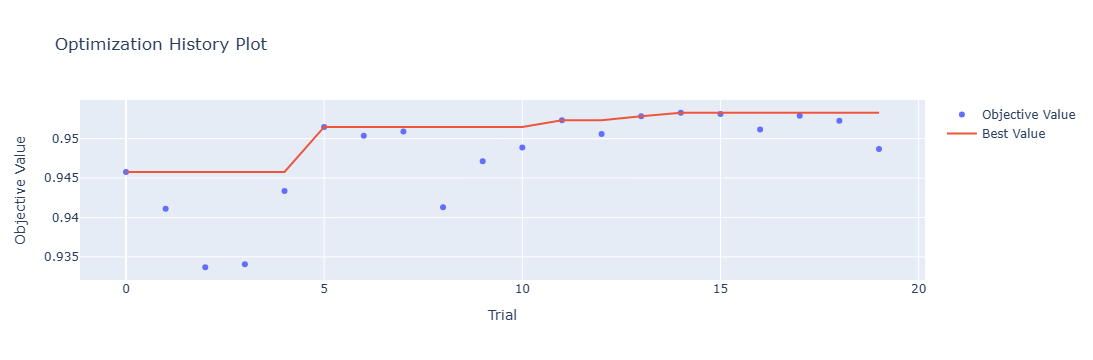

In [108]:
plot_optimization_history(study).show()

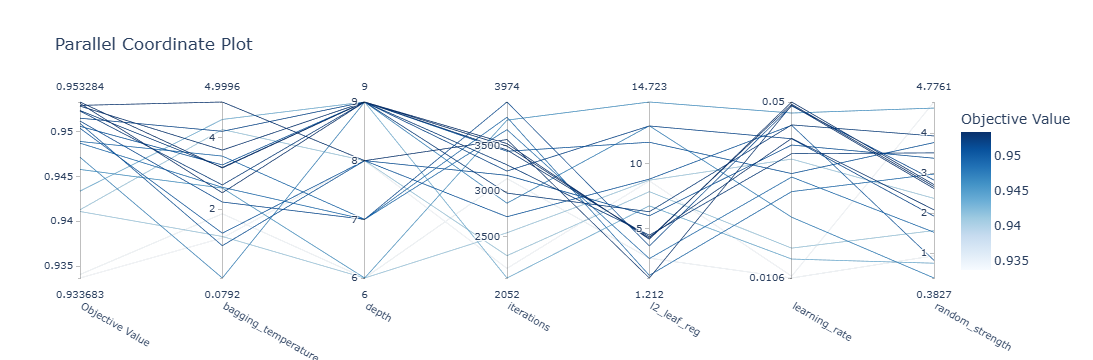

In [109]:
plot_parallel_coordinate(study).show()

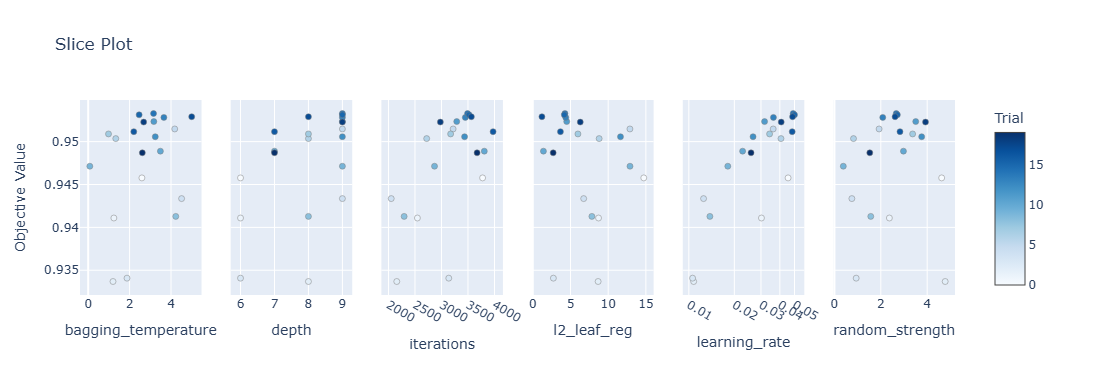

In [110]:
plot_slice(study).show()

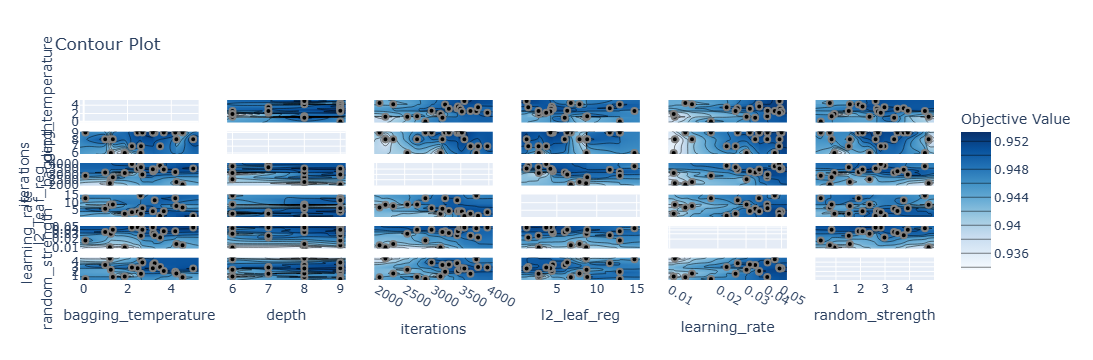

In [111]:
plot_contour(study).show()

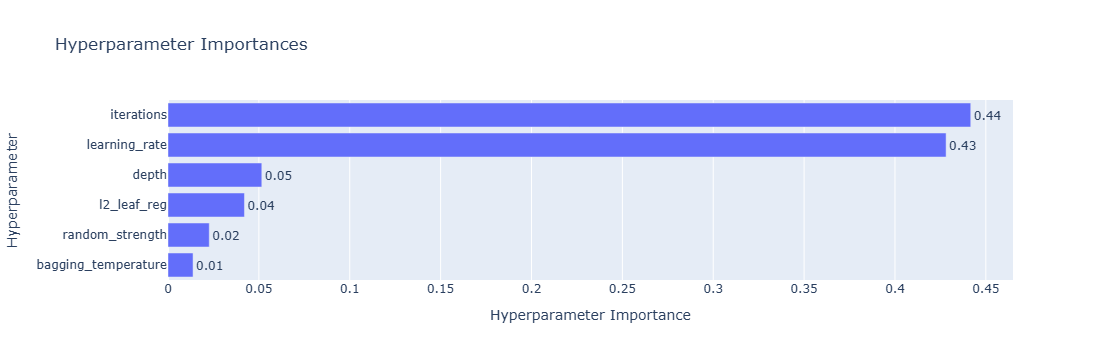

In [112]:
plot_param_importances(study).show()

In [116]:
df

,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
1,qp02zt,48,0.118507,Residential,3,1,1,31.104565,Sunny,0,0,0.0,1.000000,0,-5.462952,90.686646
2,qp08bj,48,0.027132,Residential,1,0,0,25.919267,Sunny,0,0,0.0,1.000000,0,-5.462952,90.708618
3,qp08gt,48,0.003272,Residential,1,0,0,11.141699,Rainy,0,0,0.0,1.000000,0,-5.462952,90.862427
4,qp02zq,48,0.010819,Residential,1,0,0,10.803667,Rainy,0,0,0.0,1.000000,0,-5.457458,90.675659
5,qp02zw,48,0.016262,Residential,2,0,1,8.446025,Rainy,0,0,0.0,1.000000,0,-5.457458,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,49,0.067203,Residential,1,0,0,11.501664,Rainy,2,0,0.5,0.866025,8,-5.237732,90.796509
77295,qp0d4q,49,0.022859,Residential,3,1,1,14.715254,Foggy,2,0,0.5,0.866025,8,-5.237732,90.807495
77296,qp0d4w,49,0.141342,Residential,3,1,1,19.678860,Sunny,2,0,0.5,0.866025,8,-5.237732,90.818481
77297,qp0dhw,49,0.087574,Residential,1,0,0,22.573958,Sunny,2,0,0.5,0.866025,8,-5.237732,90.906372


In [117]:
test_df

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,qp02z1,49,Residential,1,0,0,16.400264,Sunny,2,15,0.500000,0.866025,9,-5.484924,90.664673
1,qp02z9,49,Residential,1,0,0,6.476213,Snowy,2,15,0.500000,0.866025,9,-5.484924,90.686646
2,qp02yf,49,Residential,3,1,1,22.318203,Sunny,2,15,0.500000,0.866025,9,-5.479431,90.653687
3,qp02z6,49,Residential,2,0,1,11.141699,Rainy,2,15,0.500000,0.866025,9,-5.479431,90.675659
4,qp02zd,49,Residential,1,0,0,18.266162,Foggy,2,15,0.500000,0.866025,9,-5.479431,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,qp0d4q,49,Street,1,0,1,19.588991,Sunny,13,45,-0.258819,-0.965926,55,-5.237732,90.807495
41774,qp0d4w,49,Residential,2,0,1,10.735538,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.818481
41775,qp0dhq,49,Residential,2,0,1,13.223750,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.895386
41776,qp0dhw,49,Residential,2,0,1,12.510917,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.906372


In [118]:
df.to_csv("processed_train.csv", index=False)

In [119]:
test_df.to_csv("processed_test.csv", index=False)

# XGBoost

In [84]:
df = pd.read_csv("processed_train.csv")
df

,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,qp02zt,48,0.118507,Residential,3,1,1,31.104565,Sunny,0,0,0.0,1.000000,0,-5.462952,90.686646
1,qp08bj,48,0.027132,Residential,1,0,0,25.919267,Sunny,0,0,0.0,1.000000,0,-5.462952,90.708618
2,qp08gt,48,0.003272,Residential,1,0,0,11.141699,Rainy,0,0,0.0,1.000000,0,-5.462952,90.862427
3,qp02zq,48,0.010819,Residential,1,0,0,10.803667,Rainy,0,0,0.0,1.000000,0,-5.457458,90.675659
4,qp02zw,48,0.016262,Residential,2,0,1,8.446025,Rainy,0,0,0.0,1.000000,0,-5.457458,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77268,qp0d4n,49,0.067203,Residential,1,0,0,11.501664,Rainy,2,0,0.5,0.866025,8,-5.237732,90.796509
77269,qp0d4q,49,0.022859,Residential,3,1,1,14.715254,Foggy,2,0,0.5,0.866025,8,-5.237732,90.807495
77270,qp0d4w,49,0.141342,Residential,3,1,1,19.678860,Sunny,2,0,0.5,0.866025,8,-5.237732,90.818481
77271,qp0dhw,49,0.087574,Residential,1,0,0,22.573958,Sunny,2,0,0.5,0.866025,8,-5.237732,90.906372


In [85]:
test_df = pd.read_csv("processed_test.csv")

In [86]:
test_df

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,qp02z1,49,Residential,1,0,0,16.400264,Sunny,2,15,0.500000,0.866025,9,-5.484924,90.664673
1,qp02z9,49,Residential,1,0,0,6.476213,Snowy,2,15,0.500000,0.866025,9,-5.484924,90.686646
2,qp02yf,49,Residential,3,1,1,22.318203,Sunny,2,15,0.500000,0.866025,9,-5.479431,90.653687
3,qp02z6,49,Residential,2,0,1,11.141699,Rainy,2,15,0.500000,0.866025,9,-5.479431,90.675659
4,qp02zd,49,Residential,1,0,0,18.266162,Foggy,2,15,0.500000,0.866025,9,-5.479431,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,qp0d4q,49,Street,1,0,1,19.588991,Sunny,13,45,-0.258819,-0.965926,55,-5.237732,90.807495
41774,qp0d4w,49,Residential,2,0,1,10.735538,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.818481
41775,qp0dhq,49,Residential,2,0,1,13.223750,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.895386
41776,qp0dhw,49,Residential,2,0,1,12.510917,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.906372


In [28]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

In [29]:
X_xgb = df.drop(columns=['demand'])
X_test_xgb = test_df.copy()

y = df['demand']

In [30]:
cat_cols = [
    'geohash',
    'day',
    'RoadType',
    'Weather'
]

for col in cat_cols:

    combined = pd.concat([
        X_xgb[col],
        X_test_xgb[col]
    ])

    categories = pd.Categorical(combined)

    X_xgb[col] = pd.Categorical(
        X_xgb[col],
        categories=categories.categories
    ).codes

    X_test_xgb[col] = pd.Categorical(
        X_test_xgb[col],
        categories=categories.categories
    ).codes

In [31]:
X_xgb

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,25,0,1,3,1,1,31.104565,3,0,0,0.0,1.000000,0,-5.462952,90.686646
1,370,0,1,1,0,0,25.919267,3,0,0,0.0,1.000000,0,-5.462952,90.708618
2,418,0,1,1,0,0,11.141699,1,0,0,0.0,1.000000,0,-5.462952,90.862427
3,22,0,1,1,0,0,10.803667,1,0,0,0.0,1.000000,0,-5.457458,90.675659
4,28,0,1,2,0,1,8.446025,1,0,0,0.0,1.000000,0,-5.457458,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77268,1169,1,1,1,0,0,11.501664,1,2,0,0.5,0.866025,8,-5.237732,90.796509
77269,1170,1,1,3,1,1,14.715254,0,2,0,0.5,0.866025,8,-5.237732,90.807495
77270,1175,1,1,3,1,1,19.678860,3,2,0,0.5,0.866025,8,-5.237732,90.818481
77271,1223,1,1,1,0,0,22.573958,3,2,0,0.5,0.866025,8,-5.237732,90.906372


In [32]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for fold, (train_idx, val_idx) in enumerate(
    kf.split(X_xgb),
    1
):

    X_train = X_xgb.iloc[train_idx]
    X_val = X_xgb.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = XGBRegressor(
        n_estimators=2000,
        max_depth=8,
        learning_rate=0.03,

        subsample=0.8,
        colsample_bytree=0.8,

        objective='reg:squarederror',

        random_state=42,
        n_jobs=-1,
        tree_method='hist',

        early_stopping_rounds=100
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=200
    )

    pred = model.predict(X_val)

    score = r2_score(y_val, pred)

    scores.append(score)

    print(
        f"Fold {fold}: {score:.5f}"
    )

print("\nMean CV:", np.mean(scores))
print("Std CV :", np.std(scores))

[0]	validation_0-rmse:0.13776
[200]	validation_0-rmse:0.04546
[400]	validation_0-rmse:0.04110
[600]	validation_0-rmse:0.03866
[800]	validation_0-rmse:0.03703
[1000]	validation_0-rmse:0.03600
[1200]	validation_0-rmse:0.03523
[1400]	validation_0-rmse:0.03476
[1600]	validation_0-rmse:0.03443
[1800]	validation_0-rmse:0.03416
[1999]	validation_0-rmse:0.03400
Fold 1: 0.94206
[0]	validation_0-rmse:0.13796
[200]	validation_0-rmse:0.04481
[400]	validation_0-rmse:0.04042
[600]	validation_0-rmse:0.03784
[800]	validation_0-rmse:0.03636
[1000]	validation_0-rmse:0.03538
[1200]	validation_0-rmse:0.03470
[1400]	validation_0-rmse:0.03423
[1600]	validation_0-rmse:0.03389
[1800]	validation_0-rmse:0.03367
[1999]	validation_0-rmse:0.03348
Fold 2: 0.94395
[0]	validation_0-rmse:0.14075
[200]	validation_0-rmse:0.04491
[400]	validation_0-rmse:0.04034
[600]	validation_0-rmse:0.03778
[800]	validation_0-rmse:0.03619
[1000]	validation_0-rmse:0.03516
[1200]	validation_0-rmse:0.03453
[1400]	validation_0-rmse:0.03407

In [33]:
final_xgb = XGBRegressor(
    n_estimators=2000,
    max_depth=8,
    learning_rate=0.03,

    subsample=0.8,
    colsample_bytree=0.8,

    objective='reg:squarederror',

    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

final_xgb.fit(
    X_xgb,
    y,
    verbose=200
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [34]:
xgb_pred = final_xgb.predict(
    X_test_xgb
)

submission_xgb = pd.DataFrame({
    "Index": test_original["Index"],
    "demand": xgb_pred
})

submission_xgb.to_csv("submission_xgboost_baseline.csv",index=False)

submission_xgb.head()

,Index,demand
0,0,0.059388
1,1,0.045104
2,2,0.031120
3,3,0.015362
4,4,0.048915


In [20]:
import optuna
import numpy as np

from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score


def objective_xgb(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            1500,
            5000
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            4,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.08,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            10
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1,
            20
        ),

        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist"
    }

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in kf.split(X_xgb):

        X_train = X_xgb.iloc[train_idx]
        X_val = X_xgb.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = XGBRegressor(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=500
        )

        pred = model.predict(X_val)

        scores.append(
            r2_score(y_val, pred)
        )

    return np.mean(scores)

C:\Users\monis\anaconda3\envs\mlenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
study_xgb = optuna.create_study(
    direction="maximize",
    study_name="xgboost_traffic"
)

study_xgb.optimize(
    objective_xgb,
    n_trials=30,
    show_progress_bar=True
)

[I 2026-06-05 08:05:49,580] A new study created in memory with name: xgboost_traffic
  0%|                                                                                           | 0/30 [00:00<?, ?it/s]

[0]	validation_0-rmse:0.13685
[500]	validation_0-rmse:0.06811
[1000]	validation_0-rmse:0.06808
[1500]	validation_0-rmse:0.06808
[2000]	validation_0-rmse:0.06808
[2500]	validation_0-rmse:0.06808
[2510]	validation_0-rmse:0.06808
[0]	validation_0-rmse:0.13699
[500]	validation_0-rmse:0.06767
[1000]	validation_0-rmse:0.06767
[1500]	validation_0-rmse:0.06767
[2000]	validation_0-rmse:0.06767
[2500]	validation_0-rmse:0.06768
[2510]	validation_0-rmse:0.06767
[0]	validation_0-rmse:0.13986
[500]	validation_0-rmse:0.06855
[1000]	validation_0-rmse:0.06855
[1500]	validation_0-rmse:0.06855
[2000]	validation_0-rmse:0.06855
[2500]	validation_0-rmse:0.06855
[2510]	validation_0-rmse:0.06855
[0]	validation_0-rmse:0.13351
[500]	validation_0-rmse:0.06675
[1000]	validation_0-rmse:0.06675
[1500]	validation_0-rmse:0.06675
[2000]	validation_0-rmse:0.06675
[2500]	validation_0-rmse:0.06675
[2510]	validation_0-rmse:0.06675
[0]	validation_0-rmse:0.14147
[500]	validation_0-rmse:0.06871
[1000]	validation_0-rmse:0.068

Best trial: 0. Best value: 0.771446:   3%|█▌                                            | 1/30 [00:12<06:09, 12.75s/it]

[I 2026-06-05 08:06:02,332] Trial 0 finished with value: 0.7714461611180029 and parameters: {'n_estimators': 2511, 'max_depth': 7, 'learning_rate': 0.04168317488430579, 'subsample': 0.8602339133374061, 'colsample_bytree': 0.8199667670076218, 'min_child_weight': 8, 'gamma': 3.1821032551164894, 'reg_alpha': 5.278252405374132, 'reg_lambda': 13.55318069917049}. Best is trial 0 with value: 0.7714461611180029.
[0]	validation_0-rmse:0.13352
[500]	validation_0-rmse:0.06381
[1000]	validation_0-rmse:0.06381
[1500]	validation_0-rmse:0.06381
[2000]	validation_0-rmse:0.06381
[2500]	validation_0-rmse:0.06381
[3000]	validation_0-rmse:0.06381
[3500]	validation_0-rmse:0.06381
[4000]	validation_0-rmse:0.06381
[4500]	validation_0-rmse:0.06381
[4901]	validation_0-rmse:0.06381
[0]	validation_0-rmse:0.13358
[500]	validation_0-rmse:0.06313
[1000]	validation_0-rmse:0.06313
[1500]	validation_0-rmse:0.06313
[2000]	validation_0-rmse:0.06313
[2500]	validation_0-rmse:0.06313
[3000]	validation_0-rmse:0.06313
[3500]

Best trial: 1. Best value: 0.802211:   7%|███                                           | 2/30 [00:39<09:47, 20.99s/it]

...

[I 2026-06-05 08:15:50,227] Trial 27 finished with value: 0.8003521387057635 and parameters: {'n_estimators': 4673, 'max_depth': 10, 'learning_rate': 0.0792924167814845, 'subsample': 0.7541619317757504, 'colsample_bytree': 0.8507594178505313, 'min_child_weight': 10, 'gamma': 1.0679514380947641, 'reg_alpha': 0.6857589736323124, 'reg_lambda': 18.64977098649042}. Best is trial 22 with value: 0.9111234953838506.
[0]	validation_0-rmse:0.13712
[500]	validation_0-rmse:0.05488
[1000]	validation_0-rmse:0.05483
[1500]	validation_0-rmse:0.05482
[2000]	validation_0-rmse:0.05479
[2500]	validation_0-rmse:0.05479
[3000]	validation_0-rmse:0.05479
[3500]	validation_0-rmse:0.05476
[4000]	validation_0-rmse:0.05473
[4099]	validation_0-rmse:0.05473
[0]	validation_0-rmse:0.13729
[500]	validation_0-rmse:0.05395
[1000]	validation_0-rmse:0.05394
[1500]	validation_0-rmse:0.05392
[2000]	validation_0-rmse:0.05392
[2500]	validation_0-rmse:0.05392
[3000]	validation_0-rmse:0.05388
[3500]	validation_0-rmse:0.05386
[4

Best trial: 22. Best value: 0.911123:  97%|██████████████████████████████████████████▌ | 29/30 [10:22<00:22, 22.79s/it]

[I 2026-06-05 08:16:12,005] Trial 28 finished with value: 0.8559990487174385 and parameters: {'n_estimators': 4100, 'max_depth': 8, 'learning_rate': 0.03788839233268813, 'subsample': 0.7770452030159469, 'colsample_bytree': 0.940190899156228, 'min_child_weight': 3, 'gamma': 0.07173764729951593, 'reg_alpha': 2.0553694288406676, 'reg_lambda': 19.978297953871362}. Best is trial 22 with value: 0.9111234953838506.
[0]	validation_0-rmse:0.13651
[500]	validation_0-rmse:0.06502
[1000]	validation_0-rmse:0.06501
[1500]	validation_0-rmse:0.06501
[2000]	validation_0-rmse:0.06501
[2500]	validation_0-rmse:0.06501
[3000]	validation_0-rmse:0.06501
[3500]	validation_0-rmse:0.06501
[4000]	validation_0-rmse:0.06501
[4500]	validation_0-rmse:0.06501
[4978]	validation_0-rmse:0.06501
[0]	validation_0-rmse:0.13667
[500]	validation_0-rmse:0.06480
[1000]	validation_0-rmse:0.06480
[1500]	validation_0-rmse:0.06479
[2000]	validation_0-rmse:0.06477
[2500]	validation_0-rmse:0.06477
[3000]	validation_0-rmse:0.06477
[3

Best trial: 22. Best value: 0.911123: 100%|████████████████████████████████████████████| 30/30 [10:49<00:00, 21.66s/it]

[I 2026-06-05 08:16:39,315] Trial 29 finished with value: 0.7919876430091336 and parameters: {'n_estimators': 4979, 'max_depth': 9, 'learning_rate': 0.043449149975993306, 'subsample': 0.8462770394518119, 'colsample_bytree': 0.8148012759806689, 'min_child_weight': 2, 'gamma': 1.7221162448164304, 'reg_alpha': 0.2134329601850468, 'reg_lambda': 12.065839820393997}. Best is trial 22 with value: 0.9111234953838506.


In [22]:
print("Best Score:")
print(study_xgb.best_value)

print("\nBest Params:")
print(study_xgb.best_params)

Best Score:
0.9111234953838506

Best Params:
{'n_estimators': 4442, 'max_depth': 9, 'learning_rate': 0.062062577510894466, 'subsample': 0.774076481899106, 'colsample_bytree': 0.8350072130161594, 'min_child_weight': 2, 'gamma': 0.004361096063893769, 'reg_alpha': 1.2619511684926965, 'reg_lambda': 19.9759955400815}


In [25]:
import optuna
import numpy as np

from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score


def objective_xgb(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            1000,
            3000
        ),
    
        "max_depth": trial.suggest_int(
            "max_depth",
            6,
            9
        ),
    
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.02,
            0.05
        ),
    
        "subsample": trial.suggest_float(
            "subsample",
            0.7,
            1.0
        ),
    
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.7,
            1.0
        ),
    
        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            8
        ),
    
        "gamma": trial.suggest_float(
            "gamma",
            0,
            2
        ),
    
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            5
        ),
    
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1,
            10
        )
    }

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in kf.split(X_xgb):

        X_train = X_xgb.iloc[train_idx]
        X_val = X_xgb.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        

        model = XGBRegressor(
            **params,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
            early_stopping_rounds=100
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=500
        )

        pred = model.predict(X_val)

        scores.append(
            r2_score(y_val, pred)
        )

    return np.mean(scores)

In [26]:
study_xgb = optuna.create_study(
    direction="maximize",
    study_name="xgboost_traffic"
)

study_xgb.optimize(
    objective_xgb,
    n_trials=40,
    show_progress_bar=True
)

[I 2026-06-05 08:28:06,947] A new study created in memory with name: xgboost_traffic
  0%|                                                                                           | 0/40 [00:00<?, ?it/s]

[0]	validation_0-rmse:0.13595
[190]	validation_0-rmse:0.06389
[0]	validation_0-rmse:0.13613
[182]	validation_0-rmse:0.06355
[0]	validation_0-rmse:0.13897
[297]	validation_0-rmse:0.06388
[0]	validation_0-rmse:0.13268
[393]	validation_0-rmse:0.06249
[0]	validation_0-rmse:0.14054
[270]	validation_0-rmse:0.06393


Best trial: 0. Best value: 0.800065:   2%|█▏                                            | 1/40 [00:01<01:02,  1.61s/it]

[I 2026-06-05 08:28:08,556] Trial 0 finished with value: 0.8000648386488265 and parameters: {'n_estimators': 1300, 'max_depth': 7, 'learning_rate': 0.04850205214897733, 'subsample': 0.8970883647437902, 'colsample_bytree': 0.9643639629967449, 'min_child_weight': 1, 'gamma': 1.0398848964769198, 'reg_alpha': 2.8720256405705924, 'reg_lambda': 9.926336706958729}. Best is trial 0 with value: 0.8000648386488265.
[0]	validation_0-rmse:0.13845
[500]	validation_0-rmse:0.06436
[558]	validation_0-rmse:0.06436
[0]	validation_0-rmse:0.13862
[500]	validation_0-rmse:0.06410
[595]	validation_0-rmse:0.06410
[0]	validation_0-rmse:0.14147
[293]	validation_0-rmse:0.06446
[0]	validation_0-rmse:0.13515
[400]	validation_0-rmse:0.06310
[0]	validation_0-rmse:0.14313
[357]	validation_0-rmse:0.06425


Best trial: 0. Best value: 0.800065:   5%|██▎                                           | 2/40 [00:04<01:28,  2.32s/it]

...

[I 2026-06-05 08:31:26,371] Trial 37 finished with value: 0.7996382823994537 and parameters: {'n_estimators': 1694, 'max_depth': 6, 'learning_rate': 0.038649906635314465, 'subsample': 0.8869368569041541, 'colsample_bytree': 0.8077620333280724, 'min_child_weight': 8, 'gamma': 1.2826004269872024, 'reg_alpha': 0.9645089390987206, 'reg_lambda': 8.028181300509909}. Best is trial 25 with value: 0.9113162698532772.
[0]	validation_0-rmse:0.13793
[285]	validation_0-rmse:0.06085
[0]	validation_0-rmse:0.13815
[389]	validation_0-rmse:0.06055
[0]	validation_0-rmse:0.14093
[500]	validation_0-rmse:0.06091
[653]	validation_0-rmse:0.06091
[0]	validation_0-rmse:0.13464
[310]	validation_0-rmse:0.05953
[0]	validation_0-rmse:0.14258
[452]	validation_0-rmse:0.06051


Best trial: 25. Best value: 0.911316:  98%|██████████████████████████████████████████▉ | 39/40 [03:22<00:03,  3.83s/it]

[I 2026-06-05 08:31:29,117] Trial 38 finished with value: 0.8189530654433923 and parameters: {'n_estimators': 2388, 'max_depth': 7, 'learning_rate': 0.03001036550078873, 'subsample': 0.9374625860947968, 'colsample_bytree': 0.7566011322913563, 'min_child_weight': 7, 'gamma': 0.5967965613669757, 'reg_alpha': 1.5225043026392977, 'reg_lambda': 7.976611341538653}. Best is trial 25 with value: 0.9113162698532772.
[0]	validation_0-rmse:0.13746
[500]	validation_0-rmse:0.04742
[1000]	validation_0-rmse:0.04290
[1500]	validation_0-rmse:0.04051
[1957]	validation_0-rmse:0.03908
[0]	validation_0-rmse:0.13765
[500]	validation_0-rmse:0.04648
[1000]	validation_0-rmse:0.04161
[1500]	validation_0-rmse:0.03942
[1957]	validation_0-rmse:0.03822
[0]	validation_0-rmse:0.14042
[500]	validation_0-rmse:0.04643
[1000]	validation_0-rmse:0.04177
[1500]	validation_0-rmse:0.03946
[1957]	validation_0-rmse:0.03807
[0]	validation_0-rmse:0.13417
[500]	validation_0-rmse:0.04569
[1000]	validation_0-rmse:0.04115
[1500]	vali

Best trial: 39. Best value: 0.928518: 100%|████████████████████████████████████████████| 40/40 [03:37<00:00,  5.43s/it]

[I 2026-06-05 08:31:44,333] Trial 39 finished with value: 0.9285184840188598 and parameters: {'n_estimators': 1958, 'max_depth': 6, 'learning_rate': 0.034488372321764174, 'subsample': 0.9555929925271328, 'colsample_bytree': 0.8701587350811529, 'min_child_weight': 5, 'gamma': 4.2890377850379746e-05, 'reg_alpha': 0.6365575089166164, 'reg_lambda': 8.479412747137143}. Best is trial 39 with value: 0.9285184840188598.


In [35]:
print("Best Score:")
print(study_xgb.best_value)

print("\nBest Params:")
print(study_xgb.best_params)

Best Score:
0.9285184840188598

Best Params:
{'n_estimators': 1958, 'max_depth': 6, 'learning_rate': 0.034488372321764174, 'subsample': 0.9555929925271328, 'colsample_bytree': 0.8701587350811529, 'min_child_weight': 5, 'gamma': 4.2890377850379746e-05, 'reg_alpha': 0.6365575089166164, 'reg_lambda': 8.479412747137143}


In [36]:
import pandas as pd

cat = pd.read_csv("submission1.csv")
xgb = pd.read_csv("submission_xgboost_baseline.csv")

In [37]:
print(cat.head())
print(xgb.head())

print((cat["Index"] == xgb["Index"]).all())

   Index    demand
0      0  0.051890
1      1  0.034327
2      2  0.012988
3      3  0.034128
4      4  0.069989
   Index    demand
0      0  0.059388
1      1  0.045104
2      2  0.031120
3      3  0.015362
4      4  0.048915
True


In [39]:
blend_90_10 = cat.copy()

blend_90_10["demand"] = (
    0.90 * cat["demand"]
    + 0.10 * xgb["demand"]
)

blend_90_10.to_csv(
    "blend_90_10.csv",
    index=False
)

In [38]:
import numpy as np

corr = np.corrcoef(
    cat["demand"],
    xgb["demand"]
)[0,1]

print("Prediction Correlation:", corr)

Prediction Correlation: 0.9833163797511503


In [40]:
blend_95_05 = cat.copy()

blend_95_05["demand"] = (
    0.95 * cat["demand"]
    + 0.05 * xgb["demand"]
)

blend_95_05.to_csv(
    "blend_95_05.csv",
    index=False
)

In [41]:
blend_85_15 = cat.copy()

blend_85_15["demand"] = (
    0.85 * cat["demand"]
    + 0.15 * xgb["demand"]
)

blend_85_15.to_csv(
    "blend_85_15.csv",
    index=False
)

In [42]:
blend_75_25 = cat.copy()

blend_75_25["demand"] = (
    0.75 * cat["demand"]
    + 0.25 * xgb["demand"]
)

blend_75_25.to_csv(
    "blend_75_25.csv",
    index=False
)

In [43]:
blend_70_30 = cat.copy()

blend_70_30["demand"] = (
    0.70 * cat["demand"]
    + 0.30 * xgb["demand"]
)

blend_70_30.to_csv(
    "blend_70_30.csv",
    index=False
)

# checking model with shifted weights - (Not good)

In [44]:
train_dist = df['RoadType'].value_counts(normalize=True)
test_dist = test_df['RoadType'].value_counts(normalize=True)

weights_map = {
    road: test_dist[road] / train_dist[road]
    for road in train_dist.index
}

print(weights_map)

{'Residential': np.float64(0.9031085792453608), 'Street': np.float64(1.6120800034280771), 'Highway': np.float64(2.21777862631617)}


In [45]:
sample_weights = df['RoadType'].map(weights_map)

sample_weights.describe()

count    77273.000000
mean         1.000000
std          0.310275
min          0.903109
25%          0.903109
50%          0.903109
75%          0.903109
max          2.217779
Name: RoadType, dtype: float64

In [49]:
from catboost import CatBoostRegressor

X_train_final = df.drop(columns=['demand'])
y_train_final = df['demand']

cat_features = [
    'geohash',
    'day',
    'RoadType',
    'Weather'
]

X_test_final = test_df

weighted_cat = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=300
)

weighted_cat.fit(
    X_train_final,
    y_train_final,
    cat_features=cat_features,
    sample_weight=sample_weights
)

0:	learn: 0.1891057	total: 251ms	remaining: 12m 33s
300:	learn: 0.0431084	total: 23s	remaining: 3m 25s
600:	learn: 0.0375337	total: 46s	remaining: 3m 3s
900:	learn: 0.0345357	total: 1m 11s	remaining: 2m 45s
1200:	learn: 0.0327637	total: 1m 34s	remaining: 2m 21s
1500:	learn: 0.0312473	total: 1m 59s	remaining: 1m 59s
1800:	learn: 0.0299113	total: 2m 24s	remaining: 1m 36s
2100:	learn: 0.0289079	total: 2m 48s	remaining: 1m 11s
2400:	learn: 0.0281128	total: 3m 10s	remaining: 47.6s
2700:	learn: 0.0274434	total: 3m 34s	remaining: 23.7s
2999:	learn: 0.0268121	total: 3m 57s	remaining: 0us


CatBoostRegressor(depth=8, iterations=3000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=300)

In [50]:
weighted_pred = weighted_cat.predict(X_test_final)

submission_weighted = pd.DataFrame({
    "Index": test_original["Index"],
    "demand": weighted_pred
})

submission_weighted.to_csv("submission_catboost_weighted.csv",index=False)

submission_weighted.head()

,Index,demand
0,0,0.051332
1,1,0.035317
2,2,0.017245
3,3,0.037488
4,4,0.071400


In [51]:
submission_weighted.shape

(41778, 2)

In [52]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 9.3 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.3 MB/s  0:00:00



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
X_xgb

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,25,0,1,3,1,1,31.104565,3,0,0,0.0,1.000000,0,-5.462952,90.686646
1,370,0,1,1,0,0,25.919267,3,0,0,0.0,1.000000,0,-5.462952,90.708618
2,418,0,1,1,0,0,11.141699,1,0,0,0.0,1.000000,0,-5.462952,90.862427
3,22,0,1,1,0,0,10.803667,1,0,0,0.0,1.000000,0,-5.457458,90.675659
4,28,0,1,2,0,1,8.446025,1,0,0,0.0,1.000000,0,-5.457458,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77268,1169,1,1,1,0,0,11.501664,1,2,0,0.5,0.866025,8,-5.237732,90.796509
77269,1170,1,1,3,1,1,14.715254,0,2,0,0.5,0.866025,8,-5.237732,90.807495
77270,1175,1,1,3,1,1,19.678860,3,2,0,0.5,0.866025,8,-5.237732,90.818481
77271,1223,1,1,1,0,0,22.573958,3,2,0,0.5,0.866025,8,-5.237732,90.906372


In [55]:
X_lgb = X_xgb.copy()
X_test_lgb = X_test_xgb.copy()

In [56]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_lgb), 1):

    X_train = X_lgb.iloc[train_idx]
    X_val = X_lgb.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_val)

    score = r2_score(y_val, pred)

    scores.append(score)

    print(f"Fold {fold}: {score:.5f}")

print("\nMean CV:", np.mean(scores))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001965 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 777
[LightGBM] [Info] Number of data points in the train set: 61818, number of used features: 15
[LightGBM] [Info] Start training from score 0.094032
Fold 1: 0.92041
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001606 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 777
[LightGBM] [Info] Number of data points in the train set: 61818, number of used features: 15
[LightGBM] [Info] Start training from score 0.094123
Fold 2: 0.92477
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001559 seconds.
You can set `force_row_wise=true` to remove the overhe

In [58]:
final_lgb = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_lgb.fit(
    X_lgb,
    y
)

lgb_pred = final_lgb.predict(
    X_test_lgb
)

submission_lgb = pd.DataFrame({
    "Index": test_original["Index"],
    "demand": lgb_pred
})

submission_lgb.to_csv(
    "submission_lgbm.csv",
    index=False
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001517 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 777
[LightGBM] [Info] Number of data points in the train set: 77273, number of used features: 15
[LightGBM] [Info] Start training from score 0.093953


In [59]:
print(df.groupby('RoadType')['demand'].describe())

print(df.groupby('NumberofLanes')['demand'].mean())

print(df.groupby('LargeVehicles')['demand'].mean())

print(df.groupby('Weather')['demand'].mean())

               count      mean       std           min       25%       50%  \
RoadType                                                                     
Highway       3587.0  0.610555  0.229303  3.500089e-01  0.413707  0.526284   
Residential  69777.0  0.057357  0.052514  6.245650e-07  0.016210  0.040544   
Street        3909.0  0.273164  0.036693  2.200159e-01  0.240702  0.268124   

                  75%       max  
RoadType                         
Highway      0.789975  1.000000  
Residential  0.084568  1.000000  
Street       0.301890  0.349908  
NumberofLanes
1    0.088122
2    0.077480
3    0.077867
4    0.602882
5    0.607556
Name: demand, dtype: float64
LargeVehicles
0    0.073998
1    0.131931
Name: demand, dtype: float64
Weather
Foggy    0.093602
Rainy    0.094583
Snowy    0.092441
Sunny    0.094158
Name: demand, dtype: float64


In [60]:
print(df.groupby(['RoadType','NumberofLanes'])['demand'].mean())

RoadType     NumberofLanes
Highway      2                0.619140
             3                0.613320
             4                0.602882
             5                0.607556
Residential  1                0.057332
             2                0.057356
             3                0.057383
Street       1                0.273164
Name: demand, dtype: float64


In [61]:
X_lgb = X_xgb.copy()
X_test_lgb = X_test_xgb.copy()

y = df['demand']

In [62]:
import optuna
import lightgbm as lgb

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np


def objective_lgb(trial):

    params = {

        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,

        "n_estimators": trial.suggest_int(
            "n_estimators",
            1000,
            5000
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.05,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            4,
            12
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            16,
            256
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            100
        ),

        "feature_fraction": trial.suggest_float(
            "feature_fraction",
            0.6,
            1.0
        ),

        "bagging_fraction": trial.suggest_float(
            "bagging_fraction",
            0.6,
            1.0
        ),

        "lambda_l1": trial.suggest_float(
            "lambda_l1",
            0,
            10
        ),

        "lambda_l2": trial.suggest_float(
            "lambda_l2",
            0,
            10
        ),

        "random_state": 42
    }

    kf = KFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in kf.split(X_lgb):

        X_train = X_lgb.iloc[train_idx]
        X_val = X_lgb.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(
                    100,
                    verbose=False
                )
            ]
        )

        pred = model.predict(X_val)

        scores.append(
            r2_score(y_val, pred)
        )

    return np.mean(scores)

In [63]:
study_lgb = optuna.create_study(
    direction="maximize"
)

study_lgb.optimize(
    objective_lgb,
    n_trials=50,
    show_progress_bar=True
)

[I 2026-06-05 10:09:13,608] A new study created in memory with name: no-name-52c826f3-8f51-4205-a31a-8f4616859eff
Best trial: 0. Best value: 0.895186:   2%|▉                                             | 1/50 [00:09<07:49,  9.58s/it]

[I 2026-06-05 10:09:23,194] Trial 0 finished with value: 0.8951857617148082 and parameters: {'n_estimators': 4974, 'learning_rate': 0.026455955285127168, 'max_depth': 7, 'num_leaves': 24, 'min_child_samples': 99, 'feature_fraction': 0.8359790154228305, 'bagging_fraction': 0.8558588165862093, 'lambda_l1': 2.5173406895441595, 'lambda_l2': 9.058340606309855}. Best is trial 0 with value: 0.8951857617148082.


Best trial: 0. Best value: 0.895186:   4%|█▊                                            | 2/50 [00:15<05:47,  7.23s/it]

[I 2026-06-05 10:09:28,786] Trial 1 finished with value: 0.86296522629249 and parameters: {'n_estimators': 2509, 'learning_rate': 0.017363424321555992, 'max_depth': 4, 'num_leaves': 108, 'min_child_samples': 58, 'feature_fraction': 0.8102062963941299, 'bagging_fraction': 0.7500676895804268, 'lambda_l1': 2.2497325963490358, 'lambda_l2': 8.362064972528136}. Best is trial 0 with value: 0.8951857617148082.


Best trial: 0. Best value: 0.895186:   6%|██▊                                           | 3/50 [00:19<04:33,  5.83s/it]

...

[I 2026-06-05 10:21:17,936] Trial 47 finished with value: 0.868097535574615 and parameters: {'n_estimators': 2359, 'learning_rate': 0.03546388025683051, 'max_depth': 10, 'num_leaves': 166, 'min_child_samples': 21, 'feature_fraction': 0.6582102289775054, 'bagging_fraction': 0.8836640980414502, 'lambda_l1': 5.753526572044213, 'lambda_l2': 9.558881829464184}. Best is trial 11 with value: 0.9413384824179071.


Best trial: 11. Best value: 0.941338:  98%|███████████████████████████████████████████ | 49/50 [12:27<00:14, 14.87s/it]

[I 2026-06-05 10:21:40,771] Trial 48 finished with value: 0.9267556809556957 and parameters: {'n_estimators': 2977, 'learning_rate': 0.02812700788198668, 'max_depth': 9, 'num_leaves': 216, 'min_child_samples': 51, 'feature_fraction': 0.8799685220990203, 'bagging_fraction': 0.6759809647435239, 'lambda_l1': 0.9223253012328962, 'lambda_l2': 9.014870053613386}. Best is trial 11 with value: 0.9413384824179071.


Best trial: 11. Best value: 0.941338: 100%|████████████████████████████████████████████| 50/50 [12:51<00:00, 15.44s/it]

[I 2026-06-05 10:22:05,555] Trial 49 finished with value: 0.9364376838222573 and parameters: {'n_estimators': 3596, 'learning_rate': 0.04682434947782715, 'max_depth': 12, 'num_leaves': 96, 'min_child_samples': 29, 'feature_fraction': 0.6807223222988823, 'bagging_fraction': 0.8586014455232716, 'lambda_l1': 0.4185170252840912, 'lambda_l2': 9.64624762461553}. Best is trial 11 with value: 0.9413384824179071.


In [64]:
print("Best Score:")
print(study_lgb.best_value)

print("\nBest Params:")
print(study_lgb.best_params)

Best Score:
0.9413384824179071

Best Params:
{'n_estimators': 3410, 'learning_rate': 0.03361779997910425, 'max_depth': 12, 'num_leaves': 96, 'min_child_samples': 6, 'feature_fraction': 0.6775208397183186, 'bagging_fraction': 0.8986738726870829, 'lambda_l1': 0.12952903568381102, 'lambda_l2': 9.730191007162713}


In [66]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_lgb), 1):

    X_train = X_lgb.iloc[train_idx]
    X_val = X_lgb.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = LGBMRegressor(
        **study_lgb.best_params
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_val)

    score = r2_score(y_val, pred)

    scores.append(score)

    print(f"Fold {fold}: {score:.5f}")

print("\nMean CV:", np.mean(scores))

Fold 1: 0.94091
Fold 2: 0.94570
Fold 3: 0.94801
Fold 4: 0.94335
Fold 5: 0.95140

Mean CV: 0.9458754661417572


In [67]:
final_lgb = LGBMRegressor(
    **study_lgb.best_params
)

final_lgb.fit(
    X_lgb,
    y
)

lgb_pred = final_lgb.predict(
    X_test_lgb
)

submission_lgb = pd.DataFrame({
    "Index": test_original["Index"],
    "demand": lgb_pred
})

submission_lgb.to_csv(
    "submission_lgbm_optuna.csv",
    index=False
)

In [69]:
cat = pd.read_csv("submission1.csv")
lgb = pd.read_csv("submission_lgbm_optuna.csv")

corr = np.corrcoef(
    cat["demand"],
    lgb["demand"]
)[0,1]

print(corr)

0.9848446832171567


In [70]:
cat = pd.read_csv("submission1.csv")
xgb = pd.read_csv("submission_xgboost_baseline.csv")
lgb = pd.read_csv("submission_lgbm_optuna.csv")

print(
    "Cat-XGB:",
    np.corrcoef(cat["demand"], xgb["demand"])[0,1]
)

print(
    "Cat-LGB:",
    np.corrcoef(cat["demand"], lgb["demand"])[0,1]
)

print(
    "XGB-LGB:",
    np.corrcoef(xgb["demand"], lgb["demand"])[0,1]
)

Cat-XGB: 0.9833163797511503
Cat-LGB: 0.9848446832171567
XGB-LGB: 0.9944127762181968


In [71]:
blend = cat.copy()

blend["demand"] = (
    0.80 * cat["demand"]
    + 0.15 * xgb["demand"]
    + 0.05 * lgb["demand"]
)

blend.to_csv(
    "blend_cat_xgb_lgb_80_15_05.csv",
    index=False
)

In [72]:
for n in [3,4,5,6]:
    print(
        f"geo_{n}:",
        df['geohash'].str[:n].nunique()
    )

geo_3: 1
geo_4: 6
geo_5: 56
geo_6: 1249


In [73]:
geo_mean = (
    df.groupby('geohash')['demand']
      .mean()
)

print(geo_mean.describe())

count    1249.000000
mean        0.064670
std         0.099858
min         0.000495
25%         0.012661
50%         0.030807
75%         0.075227
max         0.960715
Name: demand, dtype: float64


In [74]:
print(
    df.groupby(df['geohash'].str[:5])['demand']
      .mean()
      .describe()
)

count    56.000000
mean      0.075804
std       0.056416
min       0.011380
25%       0.033576
50%       0.065287
75%       0.099612
max       0.270892
Name: demand, dtype: float64


In [75]:
print(
    df.groupby(df['geohash'].str[:4])['demand']
      .mean()
      .describe()
)

count    6.000000
mean     0.078392
std      0.042332
min      0.026204
25%      0.049445
50%      0.076936
75%      0.101750
max      0.139973
Name: demand, dtype: float64


In [76]:
print(df.groupby('day')['demand'].mean())

day
48    0.092677
49    0.105209
Name: demand, dtype: float64


In [77]:
df

,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,qp02zt,48,0.118507,Residential,3,1,1,31.104565,Sunny,0,0,0.0,1.000000,0,-5.462952,90.686646
1,qp08bj,48,0.027132,Residential,1,0,0,25.919267,Sunny,0,0,0.0,1.000000,0,-5.462952,90.708618
2,qp08gt,48,0.003272,Residential,1,0,0,11.141699,Rainy,0,0,0.0,1.000000,0,-5.462952,90.862427
3,qp02zq,48,0.010819,Residential,1,0,0,10.803667,Rainy,0,0,0.0,1.000000,0,-5.457458,90.675659
4,qp02zw,48,0.016262,Residential,2,0,1,8.446025,Rainy,0,0,0.0,1.000000,0,-5.457458,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77268,qp0d4n,49,0.067203,Residential,1,0,0,11.501664,Rainy,2,0,0.5,0.866025,8,-5.237732,90.796509
77269,qp0d4q,49,0.022859,Residential,3,1,1,14.715254,Foggy,2,0,0.5,0.866025,8,-5.237732,90.807495
77270,qp0d4w,49,0.141342,Residential,3,1,1,19.678860,Sunny,2,0,0.5,0.866025,8,-5.237732,90.818481
77271,qp0dhw,49,0.087574,Residential,1,0,0,22.573958,Sunny,2,0,0.5,0.866025,8,-5.237732,90.906372


In [78]:
features_no_geo_coords = [
    'geohash',
    'day',
    'RoadType',
    'NumberofLanes',
    'LargeVehicles',
    'Landmarks',
    'Temperature',
    'Weather',
    'hour',
    'minute',
    'hour_sin',
    'hour_cos',
    'time_slot'
]
cat_features_no_geo = [
    'geohash',
    'day',
    'RoadType',
    'Weather'
]

In [79]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

X = df[features_no_geo_coords]
y = df['demand']

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        random_seed=42,
        verbose=200
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features_no_geo
    )

    pred = model.predict(X_val)

    score = r2_score(y_val, pred)

    scores.append(score)

    print(f"Fold {fold}: {score:.5f}")

print("\nMean CV:", np.mean(scores))
print("Std CV :", np.std(scores))

0:	learn: 0.1392387	total: 133ms	remaining: 6m 38s
200:	learn: 0.0415515	total: 14.2s	remaining: 3m 18s
400:	learn: 0.0380730	total: 28.6s	remaining: 3m 5s
600:	learn: 0.0359731	total: 42.8s	remaining: 2m 50s
800:	learn: 0.0345170	total: 56.9s	remaining: 2m 36s
1000:	learn: 0.0333672	total: 1m 11s	remaining: 2m 22s
1200:	learn: 0.0323709	total: 1m 25s	remaining: 2m 8s
1400:	learn: 0.0314495	total: 1m 40s	remaining: 1m 54s
1600:	learn: 0.0307506	total: 1m 55s	remaining: 1m 40s
1800:	learn: 0.0301392	total: 2m 10s	remaining: 1m 26s
2000:	learn: 0.0295934	total: 2m 25s	remaining: 1m 12s
2200:	learn: 0.0290970	total: 2m 40s	remaining: 58.3s
2400:	learn: 0.0286727	total: 2m 55s	remaining: 43.9s
2600:	learn: 0.0281993	total: 3m 11s	remaining: 29.3s
2800:	learn: 0.0277829	total: 3m 26s	remaining: 14.7s
2999:	learn: 0.0274367	total: 3m 42s	remaining: 0us
Fold 1: 0.94541
0:	learn: 0.1391845	total: 81ms	remaining: 4m 2s
200:	learn: 0.0415031	total: 14.3s	remaining: 3m 19s
400:	learn: 0.0379393	t

In [80]:
for n in [4, 5]:
    df[f'geo_{n}'] = df['geohash'].str[:n]
    test_df[f'geo_{n}'] = test_df['geohash'].str[:n]

In [81]:
df

,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude,geo_4,geo_5
0,qp02zt,48,0.118507,Residential,3,1,1,31.104565,Sunny,0,0,0.0,1.000000,0,-5.462952,90.686646,qp02,qp02z
1,qp08bj,48,0.027132,Residential,1,0,0,25.919267,Sunny,0,0,0.0,1.000000,0,-5.462952,90.708618,qp08,qp08b
2,qp08gt,48,0.003272,Residential,1,0,0,11.141699,Rainy,0,0,0.0,1.000000,0,-5.462952,90.862427,qp08,qp08g
3,qp02zq,48,0.010819,Residential,1,0,0,10.803667,Rainy,0,0,0.0,1.000000,0,-5.457458,90.675659,qp02,qp02z
4,qp02zw,48,0.016262,Residential,2,0,1,8.446025,Rainy,0,0,0.0,1.000000,0,-5.457458,90.686646,qp02,qp02z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77268,qp0d4n,49,0.067203,Residential,1,0,0,11.501664,Rainy,2,0,0.5,0.866025,8,-5.237732,90.796509,qp0d,qp0d4
77269,qp0d4q,49,0.022859,Residential,3,1,1,14.715254,Foggy,2,0,0.5,0.866025,8,-5.237732,90.807495,qp0d,qp0d4
77270,qp0d4w,49,0.141342,Residential,3,1,1,19.678860,Sunny,2,0,0.5,0.866025,8,-5.237732,90.818481,qp0d,qp0d4
77271,qp0dhw,49,0.087574,Residential,1,0,0,22.573958,Sunny,2,0,0.5,0.866025,8,-5.237732,90.906372,qp0d,qp0dh


In [87]:
df_geo = df.copy()
test_geo = test_df.copy()

df_geo['geo_4'] = df_geo['geohash'].str[:4]
df_geo['geo_5'] = df_geo['geohash'].str[:5]

test_geo['geo_4'] = test_geo['geohash'].str[:4]
test_geo['geo_5'] = test_geo['geohash'].str[:5]

In [88]:
df_geo

,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude,geo_4,geo_5
0,qp02zt,48,0.118507,Residential,3,1,1,31.104565,Sunny,0,0,0.0,1.000000,0,-5.462952,90.686646,qp02,qp02z
1,qp08bj,48,0.027132,Residential,1,0,0,25.919267,Sunny,0,0,0.0,1.000000,0,-5.462952,90.708618,qp08,qp08b
2,qp08gt,48,0.003272,Residential,1,0,0,11.141699,Rainy,0,0,0.0,1.000000,0,-5.462952,90.862427,qp08,qp08g
3,qp02zq,48,0.010819,Residential,1,0,0,10.803667,Rainy,0,0,0.0,1.000000,0,-5.457458,90.675659,qp02,qp02z
4,qp02zw,48,0.016262,Residential,2,0,1,8.446025,Rainy,0,0,0.0,1.000000,0,-5.457458,90.686646,qp02,qp02z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77268,qp0d4n,49,0.067203,Residential,1,0,0,11.501664,Rainy,2,0,0.5,0.866025,8,-5.237732,90.796509,qp0d,qp0d4
77269,qp0d4q,49,0.022859,Residential,3,1,1,14.715254,Foggy,2,0,0.5,0.866025,8,-5.237732,90.807495,qp0d,qp0d4
77270,qp0d4w,49,0.141342,Residential,3,1,1,19.678860,Sunny,2,0,0.5,0.866025,8,-5.237732,90.818481,qp0d,qp0d4
77271,qp0dhw,49,0.087574,Residential,1,0,0,22.573958,Sunny,2,0,0.5,0.866025,8,-5.237732,90.906372,qp0d,qp0dh


In [89]:
test_geo

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude,geo_4,geo_5
0,qp02z1,49,Residential,1,0,0,16.400264,Sunny,2,15,0.500000,0.866025,9,-5.484924,90.664673,qp02,qp02z
1,qp02z9,49,Residential,1,0,0,6.476213,Snowy,2,15,0.500000,0.866025,9,-5.484924,90.686646,qp02,qp02z
2,qp02yf,49,Residential,3,1,1,22.318203,Sunny,2,15,0.500000,0.866025,9,-5.479431,90.653687,qp02,qp02y
3,qp02z6,49,Residential,2,0,1,11.141699,Rainy,2,15,0.500000,0.866025,9,-5.479431,90.675659,qp02,qp02z
4,qp02zd,49,Residential,1,0,0,18.266162,Foggy,2,15,0.500000,0.866025,9,-5.479431,90.686646,qp02,qp02z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,qp0d4q,49,Street,1,0,1,19.588991,Sunny,13,45,-0.258819,-0.965926,55,-5.237732,90.807495,qp0d,qp0d4
41774,qp0d4w,49,Residential,2,0,1,10.735538,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.818481,qp0d,qp0d4
41775,qp0dhq,49,Residential,2,0,1,13.223750,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.895386,qp0d,qp0dh
41776,qp0dhw,49,Residential,2,0,1,12.510917,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.906372,qp0d,qp0dh


In [83]:
features_geo = [
    'geohash',
    'geo_4',
    'geo_5',
    'day',
    'RoadType',
    'NumberofLanes',
    'LargeVehicles',
    'Landmarks',
    'Temperature',
    'Weather',
    'hour',
    'minute',
    'hour_sin',
    'hour_cos',
    'time_slot',
    'latitude',
    'longitude'
]
cat_features_geo = [
    'geohash',
    'geo_4',
    'geo_5',
    'day',
    'RoadType',
    'Weather'
]

In [90]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

X = df_geo[features_geo]
y = df_geo['demand']

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        random_seed=42,
        verbose=200
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features_geo
    )

    pred = model.predict(X_val)

    score = r2_score(y_val, pred)

    scores.append(score)

    print(f"Fold {fold}: {score:.5f}")

print("\nMean CV:", np.mean(scores))
print("Std CV :", np.std(scores))

0:	learn: 0.1392330	total: 35.3ms	remaining: 1m 45s
200:	learn: 0.0392575	total: 18s	remaining: 4m 10s
400:	learn: 0.0354246	total: 37.1s	remaining: 4m
600:	learn: 0.0334418	total: 56.5s	remaining: 3m 45s
800:	learn: 0.0319110	total: 1m 16s	remaining: 3m 28s
1000:	learn: 0.0306904	total: 1m 35s	remaining: 3m 11s
1200:	learn: 0.0298402	total: 1m 55s	remaining: 2m 53s
1400:	learn: 0.0291602	total: 2m 14s	remaining: 2m 33s
1600:	learn: 0.0285845	total: 2m 33s	remaining: 2m 14s
1800:	learn: 0.0280211	total: 2m 52s	remaining: 1m 55s
2000:	learn: 0.0274884	total: 3m 12s	remaining: 1m 36s
2200:	learn: 0.0270657	total: 3m 31s	remaining: 1m 16s
2400:	learn: 0.0266217	total: 3m 51s	remaining: 57.7s
2600:	learn: 0.0262186	total: 4m 11s	remaining: 38.5s
2800:	learn: 0.0258509	total: 4m 29s	remaining: 19.2s
2999:	learn: 0.0254829	total: 4m 47s	remaining: 0us
Fold 1: 0.95215
0:	learn: 0.1391868	total: 58.5ms	remaining: 2m 55s
200:	learn: 0.0396159	total: 17.1s	remaining: 3m 57s
400:	learn: 0.0359265

In [93]:
final_model_geo = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=200
)

final_model_geo.fit(
    df_geo[features_geo],
    df_geo['demand'],
    cat_features=cat_features_geo
)

0:	learn: 0.1390101	total: 61.1ms	remaining: 3m 3s
200:	learn: 0.0391801	total: 18.1s	remaining: 4m 12s
400:	learn: 0.0356289	total: 37.7s	remaining: 4m 4s
600:	learn: 0.0335960	total: 57.4s	remaining: 3m 49s
800:	learn: 0.0319603	total: 1m 17s	remaining: 3m 32s
1000:	learn: 0.0308063	total: 1m 38s	remaining: 3m 17s
1200:	learn: 0.0298805	total: 1m 58s	remaining: 2m 57s
1400:	learn: 0.0291014	total: 2m 18s	remaining: 2m 37s
1600:	learn: 0.0285508	total: 2m 38s	remaining: 2m 18s
1800:	learn: 0.0280298	total: 2m 59s	remaining: 1m 59s
2000:	learn: 0.0275758	total: 3m 18s	remaining: 1m 39s
2200:	learn: 0.0271594	total: 3m 38s	remaining: 1m 19s
2400:	learn: 0.0267982	total: 3m 57s	remaining: 59.3s
2600:	learn: 0.0264326	total: 4m 17s	remaining: 39.6s
2800:	learn: 0.0260612	total: 4m 38s	remaining: 19.8s
2999:	learn: 0.0257190	total: 4m 58s	remaining: 0us


CatBoostRegressor(depth=8, iterations=3000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

In [94]:
geo_pred = final_model_geo.predict(
    test_geo[features_geo]
)

submission_geo = pd.DataFrame({
    "Index": test_original["Index"],
    "demand": geo_pred
})

submission_geo.to_csv(
    "submission_geo45_catboost.csv",
    index=False
)

submission_geo.head()

,Index,demand
0,0,0.051170
1,1,0.030989
2,2,0.013202
3,3,0.036768
4,4,0.069431


In [95]:
cat = pd.read_csv("submission1.csv")
geo45 = pd.read_csv("submission_geo45_catboost.csv")

corr = np.corrcoef(cat["demand"],geo45["demand"])[0,1]

In [96]:
corr

np.float64(0.9987257515051546)

In [98]:
geo = pd.read_csv("submission_geo45_catboost.csv")
xgb = pd.read_csv("submission_xgboost_baseline.csv")

blend = geo.copy()

blend["demand"] = (
    0.85 * geo["demand"]
    + 0.15 * xgb["demand"]
)

blend.to_csv(
    "blend_geo45_xgb_85_15.csv",
    index=False
)

In [99]:
geo = pd.read_csv("submission_geo45_catboost.csv")
xgb = pd.read_csv("submission_xgboost_baseline.csv")

corr = np.corrcoef(
    geo["demand"],
    xgb["demand"]
)[0,1]

print(corr)

0.9830124342374172


In [100]:
blend = geo.copy()

blend["demand"] = (
    0.80 * geo["demand"]
    + 0.20 * xgb["demand"]
)

blend.to_csv(
    "blend_geo45_xgb_80_20.csv",
    index=False
)

In [101]:
geo = pd.read_csv("submission_geo45_catboost.csv")
xgb = pd.read_csv("submission_xgboost_baseline.csv")

blend = geo.copy()

blend["demand"] = (
    0.875 * geo["demand"]
    + 0.125 * xgb["demand"]
)

blend.to_csv(
    "blend_geo45_xgb_875_125.csv",
    index=False
)

In [109]:
df

,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,qp02zt,48,0.118507,Residential,3,1,1,31.104565,Sunny,0,0,0.0,1.000000,0,-5.462952,90.686646
1,qp08bj,48,0.027132,Residential,1,0,0,25.919267,Sunny,0,0,0.0,1.000000,0,-5.462952,90.708618
2,qp08gt,48,0.003272,Residential,1,0,0,11.141699,Rainy,0,0,0.0,1.000000,0,-5.462952,90.862427
3,qp02zq,48,0.010819,Residential,1,0,0,10.803667,Rainy,0,0,0.0,1.000000,0,-5.457458,90.675659
4,qp02zw,48,0.016262,Residential,2,0,1,8.446025,Rainy,0,0,0.0,1.000000,0,-5.457458,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77268,qp0d4n,49,0.067203,Residential,1,0,0,11.501664,Rainy,2,0,0.5,0.866025,8,-5.237732,90.796509
77269,qp0d4q,49,0.022859,Residential,3,1,1,14.715254,Foggy,2,0,0.5,0.866025,8,-5.237732,90.807495
77270,qp0d4w,49,0.141342,Residential,3,1,1,19.678860,Sunny,2,0,0.5,0.866025,8,-5.237732,90.818481
77271,qp0dhw,49,0.087574,Residential,1,0,0,22.573958,Sunny,2,0,0.5,0.866025,8,-5.237732,90.906372


In [110]:
test_df

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,hour_sin,hour_cos,time_slot,latitude,longitude
0,qp02z1,49,Residential,1,0,0,16.400264,Sunny,2,15,0.500000,0.866025,9,-5.484924,90.664673
1,qp02z9,49,Residential,1,0,0,6.476213,Snowy,2,15,0.500000,0.866025,9,-5.484924,90.686646
2,qp02yf,49,Residential,3,1,1,22.318203,Sunny,2,15,0.500000,0.866025,9,-5.479431,90.653687
3,qp02z6,49,Residential,2,0,1,11.141699,Rainy,2,15,0.500000,0.866025,9,-5.479431,90.675659
4,qp02zd,49,Residential,1,0,0,18.266162,Foggy,2,15,0.500000,0.866025,9,-5.479431,90.686646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,qp0d4q,49,Street,1,0,1,19.588991,Sunny,13,45,-0.258819,-0.965926,55,-5.237732,90.807495
41774,qp0d4w,49,Residential,2,0,1,10.735538,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.818481
41775,qp0dhq,49,Residential,2,0,1,13.223750,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.895386
41776,qp0dhw,49,Residential,2,0,1,12.510917,Rainy,13,45,-0.258819,-0.965926,55,-5.237732,90.906372


In [117]:
df_int = df.copy()
test_int = test_df.copy()

# Existing successful features
df_int['geo_4'] = df_int['geohash'].str[:4]
df_int['geo_5'] = df_int['geohash'].str[:5]

test_int['geo_4'] = test_int['geohash'].str[:4]
test_int['geo_5'] = test_int['geohash'].str[:5]

# New interaction features
# df_int['geo5_hour'] = (
#     df_int['geo_5']
#     + '_'
#     + df_int['hour'].astype(str)
# )

# test_int['geo5_hour'] = (
#     test_int['geo_5']
#     + '_'
#     + test_int['hour'].astype(str)
# )

df_int['geo5_road'] = (
    df_int['geo_5']
    + '_'
    + df_int['RoadType']
)

test_int['geo5_road'] = (
    test_int['geo_5']
    + '_'
    + test_int['RoadType']
)

In [118]:
features_int = [
    'geohash',
    'geo_4',
    'geo_5',
    'geo5_road',

    'day',
    'RoadType',
    'NumberofLanes',
    'LargeVehicles',
    'Landmarks',
    'Temperature',
    'Weather',

    'hour',
    'minute',
    'hour_sin',
    'hour_cos',
    'time_slot',

    'latitude',
    'longitude'
]

cat_features_int = [
    'geohash',
    'geo_4',
    'geo_5',
    'geo5_road',

    'day',
    'RoadType',
    'Weather'
]

In [121]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

X = df_int[features_int]
y = df_int['demand']

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        random_seed=42,
        verbose=200
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features_int
    )

    pred = model.predict(X_val)

    score = r2_score(y_val, pred)

    scores.append(score)

    print(f"Fold {fold}: {score:.5f}")

print("\nMean CV:", np.mean(scores))
print("Std CV :", np.std(scores))

0:	learn: 0.1391775	total: 96.9ms	remaining: 4m 50s
200:	learn: 0.0392431	total: 19.8s	remaining: 4m 36s
400:	learn: 0.0355872	total: 40.1s	remaining: 4m 19s
600:	learn: 0.0334675	total: 1m	remaining: 4m 1s
800:	learn: 0.0319629	total: 1m 21s	remaining: 3m 43s
1000:	learn: 0.0308263	total: 1m 42s	remaining: 3m 24s
1200:	learn: 0.0299152	total: 2m 2s	remaining: 3m 3s
1400:	learn: 0.0291692	total: 2m 23s	remaining: 2m 43s
1600:	learn: 0.0285104	total: 2m 44s	remaining: 2m 23s
1800:	learn: 0.0279206	total: 3m 4s	remaining: 2m 2s
2000:	learn: 0.0274044	total: 3m 25s	remaining: 1m 42s
2200:	learn: 0.0269180	total: 3m 46s	remaining: 1m 22s
2400:	learn: 0.0265137	total: 4m 7s	remaining: 1m 1s
2600:	learn: 0.0261281	total: 4m 27s	remaining: 41.1s
2800:	learn: 0.0257843	total: 4m 49s	remaining: 20.5s
2999:	learn: 0.0254681	total: 5m 10s	remaining: 0us
Fold 1: 0.95220
0:	learn: 0.1391232	total: 81.5ms	remaining: 4m 4s
200:	learn: 0.0397172	total: 18.1s	remaining: 4m 11s
400:	learn: 0.0359828	tot

In [122]:
from catboost import CatBoostRegressor

final_model_geo_road = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=300
)

final_model_geo_road.fit(
    df_int[features_int],
    df_int['demand'],
    cat_features=cat_features_int
)

0:	learn: 0.1389178	total: 136ms	remaining: 6m 47s
300:	learn: 0.0366825	total: 28.6s	remaining: 4m 16s
600:	learn: 0.0335020	total: 58.8s	remaining: 3m 54s
900:	learn: 0.0313745	total: 1m 29s	remaining: 3m 28s
1200:	learn: 0.0298261	total: 2m	remaining: 3m
1500:	learn: 0.0288296	total: 2m 32s	remaining: 2m 32s
1800:	learn: 0.0280076	total: 3m 2s	remaining: 2m 1s
2100:	learn: 0.0273274	total: 3m 35s	remaining: 1m 32s
2400:	learn: 0.0267209	total: 4m 9s	remaining: 1m 2s
2700:	learn: 0.0262024	total: 4m 42s	remaining: 31.3s
2999:	learn: 0.0256981	total: 5m 15s	remaining: 0us


CatBoostRegressor(depth=8, iterations=3000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=300)

In [123]:
pred_geo_road = final_model_geo_road.predict(
    test_int[features_int]
)

In [124]:
submission_geo_road = pd.DataFrame({
    "Index": test_original["Index"],
    "demand": pred_geo_road
})

submission_geo_road.to_csv(
    "submission_geo45_road.csv",
    index=False
)

submission_geo_road.head()

,Index,demand
0,0,0.046535
1,1,0.028518
2,2,0.008579
3,3,0.033711
4,4,0.069736


In [125]:
geo45 = pd.read_csv("submission_geo45_catboost.csv")
geo45_road = pd.read_csv("submission_geo45_road.csv")

corr = np.corrcoef(
    geo45["demand"],
    geo45_road["demand"]
)[0,1]

print("Correlation:", corr)


xgb = pd.read_csv("submission_xgboost_baseline.csv")

corr = np.corrcoef(
    geo45_road["demand"],
    xgb["demand"]
)[0,1]

print(corr)

Correlation: 0.9993041431120006
0.9828978128683783


In [126]:
geo45_road = pd.read_csv("submission_geo45_road.csv")
xgb = pd.read_csv("submission_xgboost_baseline.csv")

blend = geo45_road.copy()

blend["demand"] = (
    0.85 * geo45_road["demand"]
    + 0.15 * xgb["demand"]
)

blend.to_csv(
    "geo45_road_xgb_85_15.csv",
    index=False
)

In [ ]:
blend["demand"] = (
    0.85 * geo45_road["demand"]
    + 0.15 * xgb["demand"]
)

In [127]:
final_model_geo_road.save_model("catboost_model_geo_road.cbm")

NameError: name 'final_model' is not defined